In [134]:
# Cell 1: Project header & local file paths
RANDOM_SEED = 42

# All files are in the same folder as the notebook
DATA_PATH = "health_dataset.csv"
DATA_DICTIONARY_PATH = "Data_dictionary.txt"
MAPPING_DOC_PATH = "Health_Dataset_Decoding_and_mapping_dictionary.docx"
PDF_DOC_PATH = "document.pdf"

ARTIFACT_DIR = "artifacts"   # local folder where we'll save cleaned data & models

print("Using local files:")
print("Data CSV:", DATA_PATH)
print("Dictionary:", DATA_DICTIONARY_PATH)
print("Mapping doc:", MAPPING_DOC_PATH)
print("PDF:", PDF_DOC_PATH)
print("Artifacts directory:", ARTIFACT_DIR)
print("Random seed:", RANDOM_SEED)


Using local files:
Data CSV: health_dataset.csv
Dictionary: Data_dictionary.txt
Mapping doc: Health_Dataset_Decoding_and_mapping_dictionary.docx
PDF: document.pdf
Artifacts directory: artifacts
Random seed: 42


In [135]:
# Cell 2: Basic imports & version check

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import platform

print("Python version:", platform.python_version())
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)


Python version: 3.12.10
Pandas version: 2.3.0
NumPy version: 2.3.1
Matplotlib version: 3.10.3
Seaborn version: 0.13.2


In [136]:
# Cell 3: Load the main dataset (CSV)

# Load the CSV file into a pandas DataFrame
df_raw = pd.read_csv(DATA_PATH)

# Basic preview
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (108252, 50)


,ADM_RNO1,Province,Health_region_ grouped,Gender,Marital_status,Household,Age,Worked_job_business,Edu_level,Gen_health_state,...,Physical_vigorous_act_time,Work_hours,working_status,Aboriginal_identity,Birth_country,Immigrant,Insurance_cover,Food_security,Income_source,Total_income
0,1000,47,47906,2,1,2,3,1,3,3,...,10,38,1,2,1,2,1,0,1,5
1,100005,47,47906,1,1,2,5,6,2,3,...,0,96,6,2,1,2,1,0,2,4
2,100012,59,59914,2,2,1,5,6,1,2,...,9996,96,6,2,1,2,6,6,2,2
3,100015,13,13904,1,2,1,5,6,1,3,...,9996,96,6,2,1,2,6,0,2,3
4,100018,46,46903,1,2,1,4,2,3,5,...,9996,96,6,2,1,2,2,0,2,1


In [137]:
# Cell 4: Basic structure and datatypes

print("Column count:", len(df_raw.columns))
df_raw.info()


Column count: 50
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108252 entries, 0 to 108251
Data columns (total 50 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ADM_RNO1                    108252 non-null  int64  
 1   Province                    108252 non-null  int64  
 2   Health_region_ grouped      108252 non-null  int64  
 3   Gender                      108252 non-null  int64  
 4   Marital_status              108252 non-null  int64  
 5   Household                   108252 non-null  int64  
 6   Age                         108252 non-null  int64  
 7   Worked_job_business         108252 non-null  int64  
 8   Edu_level                   108252 non-null  int64  
 9   Gen_health_state            108252 non-null  int64  
 10  Life_satisfaction           108252 non-null  int64  
 11  Mental_health_state         108252 non-null  int64  
 12  Stress_level                108252 non-null  int64  
 1

In [138]:
# Cell 5: Unique value counts for each column (before cleaning)

unique_counts = df_raw.nunique()
unique_counts.sort_values(ascending=False).head(15)


ADM_RNO1                      108252
Total_active_time                214
Total_physical_act_time          210
Other_physical_act_time          204
Fruit_veg_con                    193
Physical_vigorous_act_time       159
Health_region_ grouped            91
weekly_alcohol                    86
Smoked                            54
Work_hours                        53
Life_satisfaction                 14
Province                          11
Work_stress                        9
Mental_health_state                8
Stress_level                       7
dtype: int64

In [139]:
# Cell X: Create working copy and helper to inspect per-column anomalies

# 1) Working copy (preserve raw)
df_clean = df_raw.copy()

# 2) Known common sentinel codes from the mapping doc (starting point).
# We'll still review each column's values to catch anything extra.
common_sentinels = {6,7,8,9,96,97,98,99,996,997,998,999,9996,9997,9998,9999}

# 3) Helper function: show top n values and flag uncommon / suspicious ones
def inspect_column(col, top_n=20):
    """
    Prints top_n most frequent values for col and shows:
      - how many are in the common sentinel list
      - any large values (heuristic: values >= 900 or <= -900)
      - unique count
    Use this to decide column-specific cleaning rules.
    """
    s = df_raw[col]
    vc = s.value_counts(dropna=False).head(top_n)
    print(f"Column: {col} — unique {s.nunique(dropna=False)} — top {top_n} values:\n")
    display(vc)
    
    # sentinel count (from common list)
    sentinel_hits = s.isin(common_sentinels).sum()
    print(f"Count of common sentinels in this column: {sentinel_hits}")
    
    # heuristic large/unusual numeric values
    if pd.api.types.is_numeric_dtype(s):
        large_values = s[ (s.abs() >= 900) & (~s.isin(common_sentinels)) ].unique()
        if len(large_values):
            print("Uncommon very large values (>=900) not in common sentinel list:", sorted(large_values))
    print("-" * 60)

# Example usage: inspect a few columns you care about
inspect_column('Total_physical_act_time')
inspect_column('Smoked')
inspect_column('Diabetic')
inspect_column('Life_satisfaction')


Column: Total_physical_act_time — unique 210 — top 20 values:



Total_physical_act_time
9996    87456
0       13255
120       782
180       694
60        679
240       468
90        440
420       411
300       375
360       354
210       326
30        308
150       257
600       140
480       135
45        123
270       102
20         98
40         97
140        84
Name: count, dtype: int64

Count of common sentinels in this column: 87568
Uncommon very large values (>=900) not in common sentinel list: [np.int64(900), np.int64(920), np.int64(925), np.int64(930), np.int64(940), np.int64(945), np.int64(960), np.int64(990), np.int64(1020), np.int64(1050), np.int64(1080), np.int64(1200), np.int64(1210), np.int64(1220), np.int64(1260), np.int64(1380), np.int64(1440), np.int64(1500), np.int64(1560), np.int64(1590), np.int64(1620), np.int64(1660), np.int64(1680), np.int64(1700), np.int64(1800), np.int64(1801), np.int64(1830), np.int64(1920), np.int64(2040), np.int64(2100), np.int64(2135), np.int64(2440), np.int64(2520), np.int64(2565), np.int64(2745), np.int64(2880), np.int64(2950), np.int64(3360), np.int64(3600), np.int64(3602), np.int64(3960), np.int64(4200), np.int64(4220), np.int64(4501), np.int64(5400), np.int64(9000), np.int64(10080)]
------------------------------------------------------------
Column: Smoked — unique 55 — top 20 values:



Smoked
996.0    92353
999.0     3571
10.0      1718
20.0      1535
25.0      1430
15.0      1132
12.0       917
5.0        717
1.0        672
2.0        542
3.0        526
8.0        473
6.0        468
4.0        416
7.0        348
13.0       227
30.0       174
9.0        124
NaN        110
18.0       105
Name: count, dtype: int64

Count of common sentinels in this column: 97337
------------------------------------------------------------
Column: Diabetic — unique 5 — top 20 values:



Diabetic
2    95749
1     9838
9     2529
7      112
8       24
Name: count, dtype: int64

Count of common sentinels in this column: 2665
------------------------------------------------------------
Column: Life_satisfaction — unique 14 — top 20 values:



Life_satisfaction
8     32001
10    22971
9     19835
7     15019
5      5566
6      5426
99     3552
4      1297
3       785
97      547
0       471
2       455
1       226
98      101
Name: count, dtype: int64

Count of common sentinels in this column: 76481
------------------------------------------------------------


In [140]:
# Cell: create df_clean and clean Total_physical_act_time (one column at a time)

# 1) Create working copy
df_clean = df_raw.copy()

# 2) Column-specific sentinel list (documented) and valid range based on mapping doc:
#    valid minutes for Total_physical_act_time: 0 - 2100 (minutes); documented sentinels include 9996/9998/9999
doc_sentinels = {9996, 9997, 9998, 9999}   # documented special codes for activity fields
# We'll also treat small set of common smaller sentinels if they appear (e.g., 996/997/998/999)
extra_sentinels = {996, 997, 998, 999}
all_sentinels = doc_sentinels.union(extra_sentinels)

# 3) Define valid numeric bounds (inclusive)
valid_min, valid_max = 0, 2100

# 4) Make cleaned column (do not overwrite original)
col = 'Total_physical_act_time'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Start by copying original values
df_clean[clean_col] = df_clean[col]

# Replace documented/extra sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(all_sentinels), clean_col] = np.nan

# Replace values outside the documented valid range (negative or > valid_max) with NaN
# This catches the undocumented huge values you observed (e.g., 9000, 10080, etc.)
df_clean.loc[ (df_clean[clean_col] < valid_min) | (df_clean[clean_col] > valid_max), clean_col] = np.nan

# Create explicit missing flag (1 = was invalid/mapped to NaN, 0 = valid)
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# 5) Quick summary to inspect the effect
summary = {
    "original_non_null": df_raw[col].notna().sum(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "top_clean_values": df_clean[clean_col].value_counts(dropna=True).head(10).to_dict()
}
summary


{'original_non_null': np.int64(108252),
 'clean_non_null': np.int64(20658),
 'num_flagged_missing': 87594,
 'top_clean_values': {0.0: 13255,
  120.0: 782,
  180.0: 694,
  60.0: 679,
  240.0: 468,
  90.0: 440,
  420.0: 411,
  300.0: 375,
  360.0: 354,
  210.0: 326}}

In [141]:
# Cell: Clean the 'Smoked' column (number of cigarettes per day)

col = 'Smoked'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Documented sentinel values for Smoked (mapping doc)
sentinels_smoked = {996, 997, 998, 999}

# Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinels with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels_smoked), clean_col] = np.nan

# Valid real-world values: 1–80 cigarettes/day (per mapping doc)
df_clean.loc[(df_clean[clean_col] < 1) | (df_clean[clean_col] > 80), clean_col] = np.nan

# Missing flag column
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Show summary
summary_smoked = {
    "original_non_null": df_raw[col].notna().sum(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "top_clean_values": df_clean[clean_col].value_counts(dropna=True).head(10).to_dict()
}

summary_smoked


{'original_non_null': np.int64(108142),
 'clean_non_null': np.int64(12218),
 'num_flagged_missing': 96034,
 'top_clean_values': {10.0: 1718,
  20.0: 1535,
  25.0: 1430,
  15.0: 1132,
  12.0: 917,
  5.0: 717,
  1.0: 672,
  2.0: 542,
  3.0: 526,
  8.0: 473}}

In [142]:
# Cell: Clean the 'Life_satisfaction' column

col = 'Life_satisfaction'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Sentinel values based on decoded mapping
sentinels_ls = {97, 98, 99}

# Step 1: Copy original column
df_clean[clean_col] = df_clean[col]

# Step 2: Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels_ls), clean_col] = np.nan

# Step 3: Enforce valid range (0–10)
df_clean.loc[(df_clean[clean_col] < 0) | (df_clean[clean_col] > 10), clean_col] = np.nan

# Step 4: Create missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5: Summary dictionary
summary_ls = {
    "original_non_null": df_raw[col].notna().sum(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "top_clean_values": df_clean[clean_col].value_counts(dropna=True).head(10).to_dict()
}

summary_ls


{'original_non_null': np.int64(108252),
 'clean_non_null': np.int64(104052),
 'num_flagged_missing': 4200,
 'top_clean_values': {8.0: 32001,
  10.0: 22971,
  9.0: 19835,
  7.0: 15019,
  5.0: 5566,
  6.0: 5426,
  4.0: 1297,
  3.0: 785,
  0.0: 471,
  2.0: 455}}

In [143]:
# Cell: Clean the 'Diabetic' yes/no column

col = 'Diabetic'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Valid yes/no codes based on mapping doc
valid_yes_no = {1, 2}

# Sentinel codes for yes/no questions
sentinels_diabetic = {7, 8, 9}

# Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels_diabetic), clean_col] = np.nan

# Enforce only 1 or 2 as valid; everything else becomes NaN (safety measure)
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Summary
summary_diabetic = {
    "original_non_null": df_raw[col].notna().sum(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_diabetic


{'original_non_null': np.int64(108252),
 'clean_non_null': np.int64(105587),
 'num_flagged_missing': 2665,
 'value_counts_clean': {2.0: 95749, 1.0: 9838}}

In [144]:
# Cell: Create binary column for Diabetic (Yes=1, No=0)

binary_col = 'Diabetic_binary'

# Start from the cleaned column (Diabetic_clean)
df_clean[binary_col] = df_clean['Diabetic_clean']

# Convert 2 -> 0 (No), keep 1 as Yes
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Summary check
df_clean[binary_col].value_counts(dropna=False)


Diabetic_binary
0.0    95749
1.0     9838
NaN     2665
Name: count, dtype: int64

In [145]:
# Cell: Clean the 'High_BP' yes/no column

col = 'High_BP'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect unique values to verify yes/no pattern
print("Unique values in raw column:", df_raw[col].unique())

# Step 2 — Valid yes/no codes
valid_yes_no = {1, 2}

# Step 3 — Sentinel codes for chronic condition columns
sentinels_bp = {7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels_bp), clean_col] = np.nan

# Enforce only {1,2} as valid
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Create binary column (Yes=1, No=0)
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0  # convert No → 0

# Step 6 — Create missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary dictionary
summary_high_bp = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict(),
}

summary_high_bp


Unique values in raw column: [2 1 7 8]


{'unique_raw_values': [2, 1, 7, 8],
 'clean_non_null': np.int64(107844),
 'num_flagged_missing': 408,
 'value_counts_clean': {2.0: 78485, 1.0: 29359},
 'value_counts_binary': {0.0: 78485, 1.0: 29359}}

In [146]:
# Cell: Clean the 'High_cholestrol' yes/no column

col = 'High_cholestrol'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect unique raw values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no
valid_yes_no = {1, 2}

# Step 3 — Sentinel values for chronic condition columns
sentinels = {7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce only valid values (1 or 2)
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Create binary column (1=yes, 0=no)
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Create missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_high_chol = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_high_chol


Unique raw values: [2 1 6 7 8]


{'unique_raw_values': [2, 1, 6, 7, 8],
 'clean_non_null': np.int64(100499),
 'num_flagged_missing': 7753,
 'value_counts_clean': {2.0: 81233, 1.0: 19266},
 'value_counts_binary': {0.0: 81233, 1.0: 19266}}

In [147]:
# Cell: Clean the 'Mood_disorder' yes/no column

col = 'Mood_disorder'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no
valid_yes_no = {1, 2}

# Step 3 — Sentinel values (based on pattern across chronic condition columns)
sentinels = {6, 7, 8, 9}   # include 6 here because some mental health columns use valid skip

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid yes/no (1 or 2)
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Create binary version
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Create missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_mood = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_mood


Unique raw values: [2 1 7 8]


{'unique_raw_values': [2, 1, 7, 8],
 'clean_non_null': np.int64(108051),
 'num_flagged_missing': 201,
 'value_counts_clean': {2.0: 97793, 1.0: 10258},
 'value_counts_binary': {0.0: 97793, 1.0: 10258}}

In [148]:
# Cell: Clean the 'Anxiety_disorder' yes/no column

col = 'Anxiety_disorder'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no responses
valid_yes_no = {1, 2}

# Step 3 — Sentinel values (consistent with other mental health variables)
sentinels = {7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid yes/no (1 or 2 only)
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Create binary version
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Create missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_anxiety = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_anxiety


Unique raw values: [2 1 7 8]


{'unique_raw_values': [2, 1, 7, 8],
 'clean_non_null': np.int64(108030),
 'num_flagged_missing': 222,
 'value_counts_clean': {2.0: 97860, 1.0: 10170},
 'value_counts_binary': {0.0: 97860, 1.0: 10170}}

In [149]:
# Cell: Clean the 'Sleep_apnea' yes/no column

col = 'Sleep_apnea'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no
valid_yes_no = {1, 2}

# Step 3 — Sentinel values
# Most chronic-condition columns use {7,8,9}. Some also use 6 (valid skip).
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce only valid yes/no
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Binary version
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_sleep_apnea = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_sleep_apnea


Unique raw values: [2 1 7 8]


{'unique_raw_values': [2, 1, 7, 8],
 'clean_non_null': np.int64(108011),
 'num_flagged_missing': 241,
 'value_counts_clean': {2.0: 99121, 1.0: 8890},
 'value_counts_binary': {0.0: 99121, 1.0: 8890}}

In [150]:
# Cell: Clean the 'Respiratory_chronic_con' yes/no column

col = 'Respiratory_chronic_con'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no responses
valid_yes_no = {1, 2}

# Step 3 — Sentinel values (many chronic columns use 6/7/8/9)
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid yes/no only
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Create binary version
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Create missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_resp = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_resp


Unique raw values: [2 1 9]


{'unique_raw_values': [2, 1, 9],
 'clean_non_null': np.int64(102679),
 'num_flagged_missing': 5573,
 'value_counts_clean': {2.0: 93936, 1.0: 8743},
 'value_counts_binary': {0.0: 93936, 1.0: 8743}}

In [151]:
# Cell: Clean the 'Musculoskeletal_con' yes/no column

col = 'Musculoskeletal_con'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no
valid_yes_no = {1, 2}

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only 1 or 2 as valid
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Binary version
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_musculo = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_musculo


Unique raw values: [2 1 6 9]


{'unique_raw_values': [2, 1, 6, 9],
 'clean_non_null': np.int64(97214),
 'num_flagged_missing': 11038,
 'value_counts_clean': {2.0: 63874, 1.0: 33340},
 'value_counts_binary': {0.0: 63874, 1.0: 33340}}

In [152]:
# Cell: Clean the 'Cardiovascular_con' yes/no column

col = 'Cardiovascular_con'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect unique raw values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no
valid_yes_no = {1, 2}

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only 1 or 2 as valid
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Binary version
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_cardio = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_cardio


Unique raw values: [2 9 1]


{'unique_raw_values': [2, 9, 1],
 'clean_non_null': np.int64(104135),
 'num_flagged_missing': 4117,
 'value_counts_clean': {2.0: 94119, 1.0: 10016},
 'value_counts_binary': {0.0: 94119, 1.0: 10016}}

In [153]:
# Cell: Clean the 'Fatigue_syndrome' yes/no column

col = 'Fatigue_syndrome'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no
valid_yes_no = {1, 2}

# Step 3 — Sentinel values (common patterns: 6,7,8,9)
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce only valid values (1 or 2)
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Binary version (Yes=1, No=0)
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_fatigue = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_fatigue


Unique raw values: [2 1 7 8]


{'unique_raw_values': [2, 1, 7, 8],
 'clean_non_null': np.int64(108001),
 'num_flagged_missing': 251,
 'value_counts_clean': {2.0: 105984, 1.0: 2017},
 'value_counts_binary': {0.0: 105984, 1.0: 2017}}

In [154]:
# Cell: Clean the 'Tobaco_use' yes/no column

col = 'Tobaco_use'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no
valid_yes_no = {1, 2}

# Step 3 — Sentinel codes
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only 1 or 2
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Binary version (Yes=1, No=0)
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_tobaco = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_tobaco


Unique raw values: [6 2 1 9]


{'unique_raw_values': [6, 2, 1, 9],
 'clean_non_null': np.int64(31276),
 'num_flagged_missing': 76976,
 'value_counts_clean': {2.0: 29582, 1.0: 1694},
 'value_counts_binary': {0.0: 29582, 1.0: 1694}}

In [155]:
# Cell: Clean the 'Drug_use' yes/no column

col = 'Drug_use'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no values
valid_yes_no = {1, 2}

# Step 3 — Sentinel codes
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only 1 or 2
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Binary conversion (Yes=1, No=0)
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_drug = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_drug


Unique raw values: [2 6 1 9]


{'unique_raw_values': [2, 6, 1, 9],
 'clean_non_null': np.int64(35220),
 'num_flagged_missing': 73032,
 'value_counts_clean': {2.0: 34392, 1.0: 828},
 'value_counts_binary': {0.0: 34392, 1.0: 828}}

In [156]:
# Cell: Clean the 'Cannabies_use' yes/no column

col = 'Cannabies_use'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no
valid_yes_no = {1, 2}

# Step 3 — Sentinel codes (behavioral columns often use 6/7/8/9)
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only 1 or 2
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Binary version
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_cannabis = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_cannabis


Unique raw values: [2 1 9 7 8]


{'unique_raw_values': [2, 1, 9, 7, 8],
 'clean_non_null': np.int64(100986),
 'num_flagged_missing': 7266,
 'value_counts_clean': {2.0: 85506, 1.0: 15480},
 'value_counts_binary': {0.0: 85506, 1.0: 15480}}

In [157]:
# Cell: Clean the 'Act_improve_health' yes/no column

col = 'Act_improve_health'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no values
valid_yes_no = {1, 2}

# Step 3 — Sentinel values (6 = valid skip; 7,8,9 = missing)
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only 1 or 2 as valid
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Create binary version
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Create missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_act_improve = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_act_improve


Unique raw values: [6 2 1 9 7 8]


{'unique_raw_values': [6, 2, 1, 9, 7, 8],
 'clean_non_null': np.int64(22658),
 'num_flagged_missing': 85594,
 'value_counts_clean': {1.0: 12005, 2.0: 10653},
 'value_counts_binary': {1.0: 12005, 0.0: 10653}}

In [158]:
# Cell: Clean the 'Gender' categorical column

col = 'Gender'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid categories (based on typical coding: 1=Male, 2=Female)
valid_vals = {1, 2}

# Step 3 — Sentinel values: 6,7,8,9
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce only valid values (1 or 2)
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_gender = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_gender


Unique raw values: [2 1]


{'unique_raw_values': [2, 1],
 'clean_non_null': np.int64(108252),
 'num_flagged_missing': 0,
 'value_counts_clean': {2.0: 58968, 1.0: 49284}}

In [159]:
# Cell: Clean the 'Marital_status' categorical column

col = 'Marital_status'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid categories 
# We do NOT assume exact category meanings yet — we only preserve non-sentinel codes.
sentinels = {6, 7, 8, 9}  # per mapping-doc logic

# Step 3 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# NOTE: We keep all remaining values (1–5 usually) as valid categories.

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_marital = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_marital


Unique raw values: [1 2 6 9]


{'unique_raw_values': [1, 2, 6, 9],
 'clean_non_null': np.int64(101378),
 'num_flagged_missing': 6874,
 'value_counts_clean': {1.0: 55861, 2.0: 45517}}

In [160]:
# Cell: Clean the 'Household' categorical column

col = 'Household'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Sentinel values (commonly 6,7,8,9)
sentinels = {6, 7, 8, 9}

# Step 3 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# NOTE: We keep all other values (1,2,3,4,5...) as valid categories.
# If unexpected values appear, we will handle them after inspecting summary.

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_household = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_household


Unique raw values: [2 1 9]


{'unique_raw_values': [2, 1, 9],
 'clean_non_null': np.int64(107730),
 'num_flagged_missing': 522,
 'value_counts_clean': {2.0: 73848, 1.0: 33882}}

In [161]:
# Cell: Clean the 'Age' categorical/ordinal column

col = 'Age'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Sentinel values
# Many surveys use 96/97/98/99; others use 6/7/8/9 depending on design.
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 3 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# NOTE: For Age, we KEEP remaining values exactly as they are.
# They represent age groups (ordinal categories).

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_age = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_age


Unique raw values: [3 5 4 2 1]


{'unique_raw_values': [3, 5, 4, 2, 1],
 'clean_non_null': np.int64(108252),
 'num_flagged_missing': 0,
 'value_counts_clean': {5.0: 47967,
  4.0: 21684,
  3.0: 16825,
  2.0: 15277,
  1.0: 6499}}

In [162]:
# Cell: Clean the 'Birth_country' categorical column

col = 'Birth_country'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Sentinel values
# Most demographic variables use 6,7,8,9 as sentinel codes.
sentinels = {6, 7, 8, 9}

# Step 3 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_birth = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_birth


Unique raw values: [1 2 9]


{'unique_raw_values': [1, 2, 9],
 'clean_non_null': np.int64(106028),
 'num_flagged_missing': 2224,
 'value_counts_clean': {1.0: 88594, 2.0: 17434}}

In [163]:
# Cell: Clean the 'Immigrant' demographic yes/no column

col = 'Immigrant'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no
valid_yes_no = {1, 2}

# Step 3 — Sentinel codes
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only valid values (1 or 2)
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Binary: Yes=1, No=0
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_immigrant = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_immigrant


Unique raw values: [2 1 9]


{'unique_raw_values': [2, 1, 9],
 'clean_non_null': np.int64(106070),
 'num_flagged_missing': 2182,
 'value_counts_clean': {2.0: 88594, 1.0: 17476},
 'value_counts_binary': {0.0: 88594, 1.0: 17476}}

In [164]:
# Cell: Clean the 'Aboriginal_identity' demographic yes/no column

col = 'Aboriginal_identity'
clean_col = col + "_clean"
binary_col = col + "_binary"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid yes/no
valid_yes_no = {1, 2}

# Step 3 — Sentinel values (demographic pattern)
sentinels = {6, 7, 8, 9}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only valid values
df_clean.loc[~df_clean[clean_col].isin(valid_yes_no), clean_col] = np.nan

# Step 5 — Binary encoding: Yes=1, No=0
df_clean[binary_col] = df_clean[clean_col]
df_clean.loc[df_clean[binary_col] == 2, binary_col] = 0

# Step 6 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 7 — Summary
summary_aboriginal = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict(),
    "value_counts_binary": df_clean[binary_col].value_counts(dropna=True).to_dict()
}

summary_aboriginal


Unique raw values: [2 9 1 8 7]


{'unique_raw_values': [2, 9, 1, 8, 7],
 'clean_non_null': np.int64(104891),
 'num_flagged_missing': 3361,
 'value_counts_clean': {2.0: 100873, 1.0: 4018},
 'value_counts_binary': {0.0: 100873, 1.0: 4018}}

In [165]:
# Cell: Clean the 'Province' categorical geographic column

col = 'Province'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Sentinel codes check
# Geographic codes rarely use 6/7/8/9, but 99 could appear depending on dataset
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 3 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN (if any)
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_province = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_province


Unique raw values: [47 59 13 46 35 12 24 10 48 11 60]


{'unique_raw_values': [47, 59, 13, 46, 35, 12, 24, 10, 48, 11, 60],
 'clean_non_null': np.int64(108252),
 'num_flagged_missing': 0,
 'value_counts_clean': {35.0: 30594,
  24.0: 19115,
  59.0: 12176,
  48.0: 11622,
  46.0: 6466,
  47.0: 6229,
  12.0: 5647,
  13.0: 5382,
  10.0: 5338,
  11.0: 4155,
  60.0: 1528}}

In [166]:
# Cell: Clean the 'Health_region_grouped' geographic/categorical column

col = 'Health_region_ grouped'  # exact column name with space/underscore
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values (first 50):", df_raw[col].unique()[:50])
print("Total unique values:", df_raw[col].nunique())

# Step 2 — Sentinel values (if present)
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 3 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_hr = {
    "unique_raw_values_sample": df_raw[col].unique()[:20].tolist(),
    "total_unique_raw": df_raw[col].nunique(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "top_clean_values": df_clean[clean_col].value_counts().head(10).to_dict()
}

summary_hr


Unique raw values (first 50): [47906 59914 13904 46903 35934 35933 12902 24909 12903 35939 59923 24906
 10911 24913 35955 35946 24908 35957 48931 48933 59932 13902 47904 24901
 11900 35995 48934 35966 24916 48932 35953 13901 24912 35960 47901 24903
 35962 10912 46901 12901 59931 59942 24915 60901 48935 35937 46902 35951
 35941 35975]
Total unique values: 91


{'unique_raw_values_sample': [47906,
  59914,
  13904,
  46903,
  35934,
  35933,
  12902,
  24909,
  12903,
  35939,
  59923,
  24906,
  10911,
  24913,
  35955,
  35946,
  24908,
  35957,
  48931,
  48933],
 'total_unique_raw': 91,
 'clean_non_null': np.int64(108252),
 'num_flagged_missing': 0,
 'top_clean_values': {11900.0: 4155,
  48932.0: 3290,
  46901.0: 3177,
  35995.0: 3166,
  48934.0: 3165,
  10911.0: 2671,
  24906.0: 2293,
  24916.0: 1949,
  12904.0: 1932,
  48933.0: 1806}}

In [167]:
# Cell: Clean the 'Gen_health_state' ordinal (1–5) column

col = 'Gen_health_state'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid range for general health rating (usually 1–5)
valid_range = set(range(1, 6))  # 1,2,3,4,5

# Step 3 — Common sentinel values for ordinal scales
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only valid 1–5 values
df_clean.loc[~df_clean[clean_col].isin(valid_range), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_gen_health = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_gen_health


Unique raw values: [3 2 5 1 4 7 8]


{'unique_raw_values': [3, 2, 5, 1, 4, 7, 8],
 'clean_non_null': np.int64(108074),
 'num_flagged_missing': 178,
 'value_counts_clean': {2.0: 39093,
  3.0: 31643,
  1.0: 21198,
  4.0: 11732,
  5.0: 4408}}

In [168]:
# Cell: Clean the 'Mental_health_state' ordinal (1–5) column

col = 'Mental_health_state'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid ordinal values
valid_range = set(range(1, 6))  # 1–5

# Step 3 — Sentinel codes
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid ordinal range
df_clean.loc[~df_clean[clean_col].isin(valid_range), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_mental_health = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_mental_health


Unique raw values: [3 5 2 1 4 9 7 8]


{'unique_raw_values': [3, 5, 2, 1, 4, 9, 7, 8],
 'clean_non_null': np.int64(104513),
 'num_flagged_missing': 3739,
 'value_counts_clean': {2.0: 38829,
  1.0: 30394,
  3.0: 26551,
  4.0: 6955,
  5.0: 1784}}

In [169]:
# Cell: Clean the 'Stress_level' ordinal (1–5) column

col = 'Stress_level'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid ordinal values: 1–5
valid_range = set(range(1, 6))

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only valid ordinal values
df_clean.loc[~df_clean[clean_col].isin(valid_range), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_stress = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_stress


Unique raw values: [2 3 4 1 5 7 8]


{'unique_raw_values': [2, 3, 4, 1, 5, 7, 8],
 'clean_non_null': np.int64(107823),
 'num_flagged_missing': 429,
 'value_counts_clean': {3.0: 40711,
  2.0: 29404,
  1.0: 18893,
  4.0: 16012,
  5.0: 2803}}

In [170]:
# Cell: Clean the 'Work_stress' ordinal (1–5) column

col = 'Work_stress'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid ordinal values (1–5)
valid_range = set(range(1, 6))

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only 1–5
df_clean.loc[~df_clean[clean_col].isin(valid_range), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_work_stress = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_work_stress


Unique raw values: [2 6 4 3 7 1 5 9 8]


{'unique_raw_values': [2, 6, 4, 3, 7, 1, 5, 9, 8],
 'clean_non_null': np.int64(42863),
 'num_flagged_missing': 65389,
 'value_counts_clean': {3.0: 18061,
  4.0: 10339,
  2.0: 8284,
  1.0: 3952,
  5.0: 2227}}

In [171]:
# Cell: Clean the 'Sense_belonging' ordinal (1–5) column

col = 'Sense_belonging'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid ordinal values
valid_range = set(range(1, 6))

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only ordinal values
df_clean.loc[~df_clean[clean_col].isin(valid_range), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_belonging = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[clean_col].isna().sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_belonging


Unique raw values: [2 3 1 4 9 7 8]


{'unique_raw_values': [2, 3, 1, 4, 9, 7, 8],
 'clean_non_null': np.int64(103490),
 'num_flagged_missing': 4762,
 'value_counts_clean': {2.0: 53145, 1.0: 23158, 3.0: 20404, 4.0: 6783}}

In [172]:
# Cell: Clean the 'working_status' categorical column

col = 'working_status '
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Sentinel values (common for work-status questions)
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 3 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# NOTE: All other values are valid categories. No binary conversion.

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_working_status = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_working_status


Unique raw values: [1 6 2 9]


{'unique_raw_values': [1, 6, 2, 9],
 'clean_non_null': np.int64(38688),
 'num_flagged_missing': 69564,
 'value_counts_clean': {1.0: 33511, 2.0: 5177}}

In [173]:
# Cell: Clean the 'Food_security' ordinal categorical column

col = 'Food_security'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values to understand coding
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Identify sentinel values (ordinal socioeconomic variables often use 6,7,8,9)
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 3 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Note: valid values (1,2,3,4...) remain as-is. No binary encoding.

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary output
summary_food_security = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_food_security


Unique raw values: [0 6 2 9 3 1]


{'unique_raw_values': [0, 6, 2, 9, 3, 1],
 'clean_non_null': np.int64(94080),
 'num_flagged_missing': 14172,
 'value_counts_clean': {0.0: 84546, 2.0: 4117, 1.0: 3188, 3.0: 2229}}

In [174]:
# Cell: Clean the 'Income_source' categorical column

col = 'Income_source'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Sentinel values (common for socioeconomic variables)
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 3 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# No ordinal or binary conversion – categories remain as numeric codes.

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_income_source = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[clean_col].isna().sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_income_source


Unique raw values: [1 2 9]


{'unique_raw_values': [1, 2, 9],
 'clean_non_null': np.int64(95408),
 'num_flagged_missing': 12844,
 'value_counts_clean': {1.0: 53284, 2.0: 42124}}

In [175]:
# Cell: Clean the 'Total_income' ordinal socioeconomic column

col = 'Total_income'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Identify sentinel codes
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 3 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# NOTE:
# For income we KEEP remaining values as they represent income brackets (ordinal).
# No binary conversion here.

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_total_income = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_total_income


Unique raw values: [5 4 2 3 1 9]


{'unique_raw_values': [5, 4, 2, 3, 1, 9],
 'clean_non_null': np.int64(105927),
 'num_flagged_missing': 2325,
 'value_counts_clean': {5.0: 49386,
  2.0: 18258,
  3.0: 17565,
  4.0: 14720,
  1.0: 5998}}

In [176]:
# Cell: Clean the 'Weight_state' ordinal categorical column

col = 'Weight_state'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid ordinal values from data dictionary: 1, 2, 3
valid_range = {1, 2, 3}

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only valid ordinal categories (1, 2, 3)
df_clean.loc[~df_clean[clean_col].isin(valid_range), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary output
summary_weight_state = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[clean_col].isna().sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_weight_state


Unique raw values: [3 1 9 2 6 7 8]


{'unique_raw_values': [3, 1, 9, 2, 6, 7, 8],
 'clean_non_null': np.int64(100784),
 'num_flagged_missing': 7468,
 'value_counts_clean': {3.0: 56085, 1.0: 41180, 2.0: 3519}}

In [177]:
df_raw["BMI_18_above"].describe(), df_raw["BMI_18_above"].unique()[:30]


(count    108252.000000
 mean          2.458892
 std           2.122562
 min           1.000000
 25%           1.000000
 50%           2.000000
 75%           2.000000
 max           9.000000
 Name: BMI_18_above, dtype: float64,
 array([2, 1, 6, 9]))

In [178]:
# Cell: Clean the 'BMI_18_above' categorical BMI status column

col = 'BMI_18_above'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values again
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid BMI status categories (from data)
valid_vals = {1, 2}   # Only possible valid values observed

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only valid values
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_bmi18 = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[clean_col].isna().sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_bmi18


Unique raw values: [2 1 6 9]


{'unique_raw_values': [2, 1, 6, 9],
 'clean_non_null': np.int64(94071),
 'num_flagged_missing': 14181,
 'value_counts_clean': {2.0: 63977, 1.0: 30094}}

In [179]:
df_raw["BMI_12_17"].describe(), df_raw["BMI_12_17"].unique()[:30]


(count    108252.000000
 mean          5.803736
 std           1.081983
 min           1.000000
 25%           6.000000
 50%           6.000000
 75%           6.000000
 max           9.000000
 Name: BMI_12_17, dtype: float64,
 array([6, 1, 9, 2]))

In [180]:
# Cell: Clean the 'BMI_12_17' categorical column

col = 'BMI_12_17'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid BMI categories (from observed values)
valid_vals = {1, 2}

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only valid BMI categories
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_bmi12 = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": df_clean[missing_flag_col].sum(),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_bmi12


Unique raw values: [6 1 9 2]


{'unique_raw_values': [6, 1, 9, 2],
 'clean_non_null': np.int64(5255),
 'num_flagged_missing': np.int64(102997),
 'value_counts_clean': {1.0: 3958, 2.0: 1297}}

In [181]:
df_raw["Fruit_veg_con"].describe(), df_raw["Fruit_veg_con"].unique()[:30]


(count    108252.000000
 mean       7605.941255
 std        4265.787233
 min           0.000000
 25%        9999.600000
 50%        9999.600000
 75%        9999.600000
 max        9999.900000
 Name: Fruit_veg_con, dtype: float64,
 array([1.3000e+00, 1.0000e+00, 9.9996e+03, 7.3000e+00, 4.4000e+00,
        2.8000e+00, 0.0000e+00, 6.4000e+00, 3.0000e+00, 2.7000e+00,
        3.1000e+00, 8.0000e+00, 1.9000e+00, 8.9000e+00, 2.9000e+00,
        2.4000e+00, 3.5000e+00, 4.1000e+00, 5.3000e+00, 3.7000e+00,
        6.6000e+00, 1.7000e+00, 5.6000e+00, 2.5000e+00, 5.7000e+00,
        5.0000e+00, 8.1000e+00, 1.6000e+00, 3.4000e+00, 1.1100e+01]))

In [182]:
# Cell: Clean the 'Fruit_veg_con' numeric diet variable

col = 'Fruit_veg_con'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect unique values again (optional)
print("Sample unique values:", df_raw[col].unique()[:20])

# Step 2 — Sentinel numeric codes
sentinels = {9999.6, 9999.9, 99996, 99997, 99998, 99999}

# Step 3 — Create cleaned column
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary dictionary
summary_fruitveg = {
    "unique_raw_values_sample": df_raw[col].unique()[:12].tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[clean_col].isna().sum()),
    "value_counts_binned": df_clean[clean_col].dropna().value_counts(bins=10).to_dict()
}

summary_fruitveg


Sample unique values: [1.3000e+00 1.0000e+00 9.9996e+03 7.3000e+00 4.4000e+00 2.8000e+00
 0.0000e+00 6.4000e+00 3.0000e+00 2.7000e+00 3.1000e+00 8.0000e+00
 1.9000e+00 8.9000e+00 2.9000e+00 2.4000e+00 3.5000e+00 4.1000e+00
 5.3000e+00 3.7000e+00]


{'unique_raw_values_sample': [1.3,
  1.0,
  9999.6,
  7.3,
  4.4,
  2.8,
  0.0,
  6.4,
  3.0,
  2.7,
  3.1,
  8.0],
 'clean_non_null': np.int64(25923),
 'num_flagged_missing': 82329,
 'value_counts_binned': {Interval(-0.0436, 4.26, closed='right'): 16892,
  Interval(4.26, 8.52, closed='right'): 8028,
  Interval(8.52, 12.78, closed='right'): 838,
  Interval(12.78, 17.04, closed='right'): 128,
  Interval(17.04, 21.3, closed='right'): 21,
  Interval(21.3, 25.56, closed='right'): 7,
  Interval(25.56, 29.82, closed='right'): 4,
  Interval(29.82, 34.08, closed='right'): 2,
  Interval(34.08, 38.34, closed='right'): 2,
  Interval(38.34, 42.6, closed='right'): 1}}

In [183]:
df_raw["Health_utility_indx"].describe(), df_raw["Health_utility_indx"].unique()[:20]


(count    108252.000000
 mean          2.187248
 std           1.809769
 min           1.000000
 25%           2.000000
 50%           2.000000
 75%           2.000000
 max           9.000000
 Name: Health_utility_indx, dtype: float64,
 array([1, 9, 2]))

In [184]:
# Cell: Clean the 'Health_utility_indx' binary health indicator

col = 'Health_utility_indx'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid values (binary)
valid_vals = {1, 2}

# Step 3 — Sentinel values
sentinels = {9, 96, 97, 98, 99}

# Step 4 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid values
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary output
summary_hu = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": df_clean[missing_flag_col].sum(),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_hu


Unique raw values: [1 9 2]


{'unique_raw_values': [1, 9, 2],
 'clean_non_null': np.int64(101491),
 'num_flagged_missing': np.int64(6761),
 'value_counts_clean': {2.0: 74434, 1.0: 27057}}

In [185]:
df_raw["Pain_status"].describe(), df_raw["Pain_status"].unique()


(count    108252.000000
 mean          1.311043
 std           0.625889
 min           1.000000
 25%           1.000000
 50%           1.000000
 75%           2.000000
 max           9.000000
 Name: Pain_status, dtype: float64,
 array([2, 1, 9]))

In [186]:
# Cell: Clean the 'Pain_status' binary health indicator

col = 'Pain_status'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid values
valid_vals = {1, 2}

# Step 3 — Sentinel values
sentinels = {9, 96, 97, 98, 99}

# Step 4 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid categories
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_pain = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": df_clean[missing_flag_col].sum(),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_pain


Unique raw values: [2 1 9]


{'unique_raw_values': [2, 1, 9],
 'clean_non_null': np.int64(107909),
 'num_flagged_missing': np.int64(343),
 'value_counts_clean': {1.0: 76982, 2.0: 30927}}

In [187]:
df_raw["Act_improve_health"].describe(), df_raw["Act_improve_health"].unique()


(count    108252.000000
 mean          5.068341
 std           1.878280
 min           1.000000
 25%           6.000000
 50%           6.000000
 75%           6.000000
 max           9.000000
 Name: Act_improve_health, dtype: float64,
 array([6, 2, 1, 9, 7, 8]))

In [188]:
# Cell: Clean the 'Act_improve_health' behavioral variable

col = 'Act_improve_health'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid categories
valid_vals = {1, 2}

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Keep only valid responses
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_act = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_act


Unique raw values: [6 2 1 9 7 8]


{'unique_raw_values': [6, 2, 1, 9, 7, 8],
 'clean_non_null': np.int64(22658),
 'num_flagged_missing': 85594,
 'value_counts_clean': {1.0: 12005, 2.0: 10653}}

In [189]:
df_raw["Work_hours "].describe(), df_raw["Work_hours "].unique()[:30]


(count    108252.000000
 mean         75.402496
 std          28.343824
 min           0.000000
 25%          42.000000
 50%          96.000000
 75%          96.000000
 max          99.000000
 Name: Work_hours , dtype: float64,
 array([38, 96, 50, 35, 45, 40, 39, 25, 30, 20, 99,  6,  8, 24, 32, 48, 28,
        42, 26, 37, 15, 10, 36,  9, 44,  4, 33, 49, 12, 18]))

In [190]:
# Cell: Clean the 'Work_hours' numeric variable

col = 'Work_hours '
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw values again
print("Unique raw values:", df_raw[col].unique()[:20])

# Step 2 — Sentinel values
sentinels = {96, 99}

# Step 3 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_workhours = {
    "unique_raw_values_sample": df_raw[col].unique()[:20].tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[clean_col].isna().sum()),
    "min_clean": float(df_clean[clean_col].min(skipna=True)),
    "max_clean": float(df_clean[clean_col].max(skipna=True)),
    "median_clean": float(df_clean[clean_col].median(skipna=True))
}

summary_workhours


Unique raw values: [38 96 50 35 45 40 39 25 30 20 99  6  8 24 32 48 28 42 26 37]


C:\Users\savin\AppData\Local\Temp\ipykernel_9540\3233551297.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[clean_col] = df_clean[col]
C:\Users\savin\AppData\Local\Temp\ipykernel_9540\3233551297.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)


{'unique_raw_values_sample': [38,
  96,
  50,
  35,
  45,
  40,
  39,
  25,
  30,
  20,
  99,
  6,
  8,
  24,
  32,
  48,
  28,
  42,
  26,
  37],
 'clean_non_null': np.int64(38688),
 'num_flagged_missing': 69564,
 'min_clean': 0.0,
 'max_clean': 50.0,
 'median_clean': 40.0}

In [191]:
df_raw["weekly_alcohol"].describe(), df_raw["weekly_alcohol"].unique()[:30]


(count    108252.000000
 mean        659.998938
 std         469.487701
 min           0.000000
 25%           5.000000
 50%         996.000000
 75%         996.000000
 max         999.000000
 Name: weekly_alcohol, dtype: float64,
 array([996,   2,   4,   3,  11,   0,   1,  10,  12,   5,  35, 999,   6,
          7,   8,  14,  22,  36,  33,  18,  17,  47,  19,  15,  42,  23,
         24,  25,  16,   9]))

In [192]:
# Cell: Clean 'weekly_alcohol' numeric consumption variable

col = 'weekly_alcohol'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values sample:", df_raw[col].unique()[:20])

# Step 2 — Sentinel values
sentinels = {996, 999}

# Step 3 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_alcohol = {
    "unique_raw_values_sample": df_raw[col].unique()[:20].tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "min_clean": float(df_clean[clean_col].min(skipna=True)),
    "max_clean": float(df_clean[clean_col].max(skipna=True)),
    "median_clean": float(df_clean[clean_col].median(skipna=True))
}

summary_alcohol


Unique raw values sample: [996   2   4   3  11   0   1  10  12   5  35 999   6   7   8  14  22  36
  33  18]


C:\Users\savin\AppData\Local\Temp\ipykernel_9540\252955301.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[clean_col] = df_clean[col]
C:\Users\savin\AppData\Local\Temp\ipykernel_9540\252955301.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)


{'unique_raw_values_sample': [996,
  2,
  4,
  3,
  11,
  0,
  1,
  10,
  12,
  5,
  35,
  999,
  6,
  7,
  8,
  14,
  22,
  36,
  33,
  18],
 'clean_non_null': np.int64(36674),
 'num_flagged_missing': 71578,
 'min_clean': 0.0,
 'max_clean': 140.0,
 'median_clean': 1.0}

In [193]:
# Cell: Clean the 'Smoked' numeric cigarette consumption variable

col = 'Smoked'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values (sample)
print("Unique raw values sample:", df_raw[col].unique()[:20])

# Step 2 — Sentinel values
sentinels = {996, 999}

# Step 3 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_smoked = {
    "unique_raw_values_sample": df_raw[col].unique()[:20].tolist(),
    "clean_non_null": df_clean[clean_col].notna().sum(),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "min_clean": float(df_clean[clean_col].min(skipna=True)),
    "max_clean": float(df_clean[clean_col].max(skipna=True)),
    "median_clean": float(df_clean[clean_col].median(skipna=True))
}

summary_smoked


Unique raw values sample: [996. 999.  35.   7.  10.  15.  55.  25.  20.   3.   2.   1.   5.  12.
   6.  17.   4.   8.  50.  18.]


{'unique_raw_values_sample': [996.0,
  999.0,
  35.0,
  7.0,
  10.0,
  15.0,
  55.0,
  25.0,
  20.0,
  3.0,
  2.0,
  1.0,
  5.0,
  12.0,
  6.0,
  17.0,
  4.0,
  8.0,
  50.0,
  18.0],
 'clean_non_null': np.int64(12218),
 'num_flagged_missing': 96034,
 'min_clean': 1.0,
 'max_clean': 80.0,
 'median_clean': 12.0}

In [194]:
df_raw["Tobaco_use"].describe(), df_raw["Tobaco_use"].unique()


(count    108252.000000
 mean          4.829121
 std           1.842264
 min           1.000000
 25%           2.000000
 50%           6.000000
 75%           6.000000
 max           9.000000
 Name: Tobaco_use, dtype: float64,
 array([6, 2, 1, 9]))

In [195]:
# Cell: Clean 'Tobaco_use' binary yes/no variable

col = 'Tobaco_use'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid responses
valid_vals = {1, 2}

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Remove values outside valid range
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_tobacco = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": int(df_clean[clean_col].notna().sum()),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_tobacco


Unique raw values: [6 2 1 9]


{'unique_raw_values': [6, 2, 1, 9],
 'clean_non_null': 31276,
 'num_flagged_missing': 76976,
 'value_counts_clean': {2.0: 29582, 1.0: 1694}}

In [196]:
df_raw["Cannabies_use"].describe(), df_raw["Cannabies_use"].unique()


(count    108252.000000
 mean          2.326350
 std           1.821908
 min           1.000000
 25%           2.000000
 50%           2.000000
 75%           2.000000
 max           9.000000
 Name: Cannabies_use, dtype: float64,
 array([2, 1, 9, 7, 8]))

In [197]:
# Cell: Clean 'Cannabies_use' binary yes/no variable

col = 'Cannabies_use'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid responses
valid_vals = {1, 2}

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid values only
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_cannabis = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": int(df_clean[clean_col].notna().sum()),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_cannabis


Unique raw values: [2 1 9 7 8]


{'unique_raw_values': [2, 1, 9, 7, 8],
 'clean_non_null': 100986,
 'num_flagged_missing': 7266,
 'value_counts_clean': {2.0: 85506, 1.0: 15480}}

In [198]:
df_raw["Drug_use"].describe(), df_raw["Drug_use"].unique()


(count    108252.000000
 mean          4.726222
 std           1.938513
 min           1.000000
 25%           2.000000
 50%           6.000000
 75%           6.000000
 max           9.000000
 Name: Drug_use, dtype: float64,
 array([2, 6, 1, 9]))

In [199]:
# Cell: Clean 'Drug_use' binary variable

col = 'Drug_use'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid values
valid_vals = {1, 2}

# Step 3 — Sentinel values
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 4 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid ranges
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_drug = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": int(df_clean[clean_col].notna().sum()),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_drug


Unique raw values: [2 6 1 9]


{'unique_raw_values': [2, 6, 1, 9],
 'clean_non_null': 35220,
 'num_flagged_missing': 73032,
 'value_counts_clean': {2.0: 34392, 1.0: 828}}

In [200]:
df_raw["Total_active_time"].describe(), df_raw["Total_active_time"].unique()[:30]


(count    108252.000000
 mean       8109.791366
 std        3889.939841
 min           0.000000
 25%        9996.000000
 50%        9996.000000
 75%        9996.000000
 max       10080.000000
 Name: Total_active_time, dtype: float64,
 array([   0, 9996,  245,  120,   60,  180,  420, 1650,   45,  300,  210,
         240, 9997,   50,   30,  100, 4200, 1200,   40,   25,   20,  200,
         630,  140,   90, 1500,  840,  105, 2400,  540]))

In [201]:
# Cell: Clean the 'Total_active_time' numeric variable

col = 'Total_active_time'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw values (sample)
print("Unique raw values sample:", df_raw[col].unique()[:20])

# Step 2 — Sentinel values
sentinels = {9996, 9997, 9998, 9999}

# Step 3 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_total_active = {
    "unique_raw_values_sample": df_raw[col].unique()[:20].tolist(),
    "clean_non_null": int(df_clean[clean_col].notna().sum()),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "min_clean": float(df_clean[clean_col].min(skipna=True)),
    "max_clean": float(df_clean[clean_col].max(skipna=True)),
    "median_clean": float(df_clean[clean_col].median(skipna=True))
}

summary_total_active


Unique raw values sample: [   0 9996  245  120   60  180  420 1650   45  300  210  240 9997   50
   30  100 4200 1200   40   25]


C:\Users\savin\AppData\Local\Temp\ipykernel_9540\3650741029.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[clean_col] = df_clean[col]
C:\Users\savin\AppData\Local\Temp\ipykernel_9540\3650741029.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)


{'unique_raw_values_sample': [0,
  9996,
  245,
  120,
  60,
  180,
  420,
  1650,
  45,
  300,
  210,
  240,
  9997,
  50,
  30,
  100,
  4200,
  1200,
  40,
  25],
 'clean_non_null': 20629,
 'num_flagged_missing': 87623,
 'min_clean': 0.0,
 'max_clean': 10080.0,
 'median_clean': 0.0}

In [202]:
df_raw["Other_physical_act_time"].describe(), df_raw["Other_physical_act_time"].unique()[:30]


(count    108252.000000
 mean       8123.279265
 std        3869.846612
 min           0.000000
 25%        9996.000000
 50%        9996.000000
 75%        9996.000000
 max        9999.000000
 Name: Other_physical_act_time, dtype: float64,
 array([  60,    0, 9996,   30, 3360,   20,   50, 1200,  300,   90,  120,
        1800,  360,   45, 1680,  420,  390, 9997,  240,  720,  210,  180,
        2880,  540, 2400,  840,  270, 1500, 2940,  930]))

In [203]:
# Cell: Clean the 'Other_physical_act_time' numeric variable

col = 'Other_physical_act_time'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw values (sample)
print("Unique raw values sample:", df_raw[col].unique()[:20])

# Step 2 — Sentinel values
sentinels = {9996, 9997, 9998, 9999}

# Step 3 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_other_pa = {
    "unique_raw_values_sample": df_raw[col].unique()[:20].tolist(),
    "clean_non_null": int(df_clean[clean_col].notna().sum()),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "min_clean": float(df_clean[clean_col].min(skipna=True)),
    "max_clean": float(df_clean[clean_col].max(skipna=True)),
    "median_clean": float(df_clean[clean_col].median(skipna=True))
}

summary_other_pa


Unique raw values sample: [  60    0 9996   30 3360   20   50 1200  300   90  120 1800  360   45
 1680  420  390 9997  240  720]


C:\Users\savin\AppData\Local\Temp\ipykernel_9540\53885553.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[clean_col] = df_clean[col]
C:\Users\savin\AppData\Local\Temp\ipykernel_9540\53885553.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)


{'unique_raw_values_sample': [60,
  0,
  9996,
  30,
  3360,
  20,
  50,
  1200,
  300,
  90,
  120,
  1800,
  360,
  45,
  1680,
  420,
  390,
  9997,
  240,
  720],
 'clean_non_null': 20578,
 'num_flagged_missing': 87674,
 'min_clean': 0.0,
 'max_clean': 8101.0,
 'median_clean': 0.0}

In [204]:
df_raw["Physical_vigorous_act_time"].describe(), df_raw["Physical_vigorous_act_time"].unique()[:30]


(count    108252.000000
 mean       8118.493497
 std        3897.281466
 min           0.000000
 25%        9996.000000
 50%        9996.000000
 75%        9996.000000
 max        9999.000000
 Name: Physical_vigorous_act_time, dtype: float64,
 array([  10,    0, 9996,  120,   30,    5,    1,  360,  135,  300,   45,
         150, 9999,   70,   60,  180,  240,  960,   20,   15,   90,    4,
         140,   35,  480,  620,  450,  100, 9997, 1200]))

In [205]:
# Cell: Clean the 'Physical_vigorous_act_time' numeric variable

col = 'Physical_vigorous_act_time'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw values (sample)
print("Unique raw values sample:", df_raw[col].unique()[:20])

# Step 2 — Sentinel values
sentinels = {9996, 9997, 9998, 9999}

# Step 3 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_vigorous_pa = {
    "unique_raw_values_sample": df_raw[col].unique()[:20].tolist(),
    "clean_non_null": int(df_clean[clean_col].notna().sum()),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "min_clean": float(df_clean[clean_col].min(skipna=True)),
    "max_clean": float(df_clean[clean_col].max(skipna=True)),
    "median_clean": float(df_clean[clean_col].median(skipna=True))
}

summary_vigorous_pa


Unique raw values sample: [  10    0 9996  120   30    5    1  360  135  300   45  150 9999   70
   60  180  240  960   20   15]


C:\Users\savin\AppData\Local\Temp\ipykernel_9540\2301143066.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[clean_col] = df_clean[col]
C:\Users\savin\AppData\Local\Temp\ipykernel_9540\2301143066.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)


{'unique_raw_values_sample': [10,
  0,
  9996,
  120,
  30,
  5,
  1,
  360,
  135,
  300,
  45,
  150,
  9999,
  70,
  60,
  180,
  240,
  960,
  20,
  15],
 'clean_non_null': 20397,
 'num_flagged_missing': 87855,
 'min_clean': 0.0,
 'max_clean': 8400.0,
 'median_clean': 0.0}

In [206]:
df_raw["Aboriginal_identity"].describe(), df_raw["Aboriginal_identity"].unique()


(count    108252.000000
 mean          2.171618
 std           1.193865
 min           1.000000
 25%           2.000000
 50%           2.000000
 75%           2.000000
 max           9.000000
 Name: Aboriginal_identity, dtype: float64,
 array([2, 9, 1, 8, 7]))

In [207]:
# Cell: Clean the 'Aboriginal_identity' binary demographic variable

col = 'Aboriginal_identity'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid values
valid_vals = {1, 2}

# Step 3 — Sentinel values
sentinels = {7, 8, 9, 6, 96, 97, 98, 99}

# Step 4 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid values only
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 5 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 6 — Summary
summary_aboriginal = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": int(df_clean[clean_col].notna().sum()),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_aboriginal


Unique raw values: [2 9 1 8 7]


{'unique_raw_values': [2, 9, 1, 8, 7],
 'clean_non_null': 104891,
 'num_flagged_missing': 3361,
 'value_counts_clean': {2.0: 100873, 1.0: 4018}}

In [208]:
# Cell: Clean the 'Birth_country' binary demographic variable

col = 'Birth_country'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Define valid and sentinel values
valid_vals = {1, 2}
sentinels = {6, 7, 8, 9, 96, 97, 98, 99}

# Step 3 — Create cleaned version
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid values only
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_birth_country = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": int(df_clean[clean_col].notna().sum()),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_birth_country


Unique raw values: [1 2 9]


{'unique_raw_values': [1, 2, 9],
 'clean_non_null': 106028,
 'num_flagged_missing': 2224,
 'value_counts_clean': {1.0: 88594, 2.0: 17434}}

In [209]:
df_raw["Income_source"].describe(), df_raw["Income_source"].unique()[:30]


(count    108252.000000
 mean          2.338322
 std           2.488297
 min           1.000000
 25%           1.000000
 50%           2.000000
 75%           2.000000
 max           9.000000
 Name: Income_source, dtype: float64,
 array([1, 2, 9]))

In [210]:
# Cell: Clean the 'Income_source' categorical variable

col = 'Income_source'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid and sentinel values
valid_vals = {1, 2}
sentinels = {9, 96, 97, 98, 99}

# Step 3 — Create cleaned copy
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid values only
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_income_source = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": int(df_clean[clean_col].notna().sum()),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_income_source


Unique raw values: [1 2 9]


{'unique_raw_values': [1, 2, 9],
 'clean_non_null': 95408,
 'num_flagged_missing': 12844,
 'value_counts_clean': {1.0: 53284, 2.0: 42124}}

In [211]:
df_raw["Total_income"].describe(), df_raw["Total_income"].unique()[:40]


(count    108252.000000
 mean          3.897794
 std           1.522599
 min           1.000000
 25%           3.000000
 50%           4.000000
 75%           5.000000
 max           9.000000
 Name: Total_income, dtype: float64,
 array([5, 4, 2, 3, 1, 9]))

In [212]:
# Cell: Clean the 'Total_income' ordinal income bracket variable

col = 'Total_income'
clean_col = col + "_clean"
missing_flag_col = col + "_missing_flag"

# Step 1 — Inspect raw unique values
print("Unique raw values:", df_raw[col].unique())

# Step 2 — Valid range and sentinel
valid_vals = {1, 2, 3, 4, 5}
sentinels = {9, 96, 97, 98, 99}

# Step 3 — Create cleaned version
df_clean[clean_col] = df_clean[col]

# Replace sentinel values with NaN
df_clean.loc[df_clean[clean_col].isin(sentinels), clean_col] = np.nan

# Enforce valid values only
df_clean.loc[~df_clean[clean_col].isin(valid_vals), clean_col] = np.nan

# Step 4 — Missing flag
df_clean[missing_flag_col] = df_clean[clean_col].isna().astype(int)

# Step 5 — Summary
summary_total_income = {
    "unique_raw_values": df_raw[col].unique().tolist(),
    "clean_non_null": int(df_clean[clean_col].notna().sum()),
    "num_flagged_missing": int(df_clean[missing_flag_col].sum()),
    "value_counts_clean": df_clean[clean_col].value_counts(dropna=True).to_dict()
}

summary_total_income


Unique raw values: [5 4 2 3 1 9]


{'unique_raw_values': [5, 4, 2, 3, 1, 9],
 'clean_non_null': 105927,
 'num_flagged_missing': 2325,
 'value_counts_clean': {5.0: 49386,
  2.0: 18258,
  3.0: 17565,
  4.0: 14720,
  1.0: 5998}}

In [213]:
# Cell: Defragment df_clean to improve performance and remove warnings
df_clean = df_clean.copy()


In [214]:
# EDA Step 1: Preview first 5 rows
df_clean.head()


,ADM_RNO1,Province,Health_region_ grouped,Gender,Marital_status,Household,Age,Worked_job_business,Edu_level,Gen_health_state,...,Work_hours _clean,Work_hours _missing_flag,weekly_alcohol_clean,weekly_alcohol_missing_flag,Total_active_time_clean,Total_active_time_missing_flag,Other_physical_act_time_clean,Other_physical_act_time_missing_flag,Physical_vigorous_act_time_clean,Physical_vigorous_act_time_missing_flag
0,1000,47,47906,2,1,2,3,1,3,3,...,38.0,0,NaN,1,0.0,0,60.0,0,10.0,0
1,100005,47,47906,1,1,2,5,6,2,3,...,NaN,1,NaN,1,0.0,0,0.0,0,0.0,0
2,100012,59,59914,2,2,1,5,6,1,2,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
3,100015,13,13904,1,2,1,5,6,1,3,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
4,100018,46,46903,1,2,1,4,2,3,5,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1


In [215]:
# EDA Step 1: Dataset info
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108252 entries, 0 to 108251
Columns: 158 entries, ADM_RNO1 to Physical_vigorous_act_time_missing_flag
dtypes: float64(64), int64(94)
memory usage: 130.5 MB


In [216]:
# EDA Step 2: Missing value count per column
missing_summary = df_clean.isna().sum().sort_values(ascending=False)
missing_summary.head(20)  # show top 20


BMI_12_17_clean                     102997
Smoked_clean                         96034
Physical_vigorous_act_time_clean     87855
Other_physical_act_time_clean        87674
Total_active_time_clean              87623
Total_physical_act_time_clean        87594
Act_improve_health_clean             85594
Act_improve_health_binary            85594
Fruit_veg_con_clean                  82329
Tobaco_use_binary                    76976
Tobaco_use_clean                     76976
Drug_use_binary                      73032
Drug_use_clean                       73032
weekly_alcohol_clean                 71578
working_status _clean                69564
Work_hours _clean                    69564
Work_stress_clean                    65389
BMI_18_above_clean                   14181
Food_security_clean                  14172
Income_source_clean                  12844
dtype: int64

In [217]:
# EDA Step 2: Missing value percentage
missing_pct = (df_clean.isna().sum() / len(df_clean) * 100).sort_values(ascending=False)
missing_pct.head(20)


BMI_12_17_clean                     95.145586
Smoked_clean                        88.713373
Physical_vigorous_act_time_clean    81.157854
Other_physical_act_time_clean       80.990651
Total_active_time_clean             80.943539
Total_physical_act_time_clean       80.916750
Act_improve_health_clean            79.069209
Act_improve_health_binary           79.069209
Fruit_veg_con_clean                 76.053098
Tobaco_use_binary                   71.108155
Tobaco_use_clean                    71.108155
Drug_use_binary                     67.464804
Drug_use_clean                      67.464804
weekly_alcohol_clean                66.121642
working_status _clean               64.261168
Work_hours _clean                   64.261168
Work_stress_clean                   60.404427
BMI_18_above_clean                  13.099989
Food_security_clean                 13.091675
Income_source_clean                 11.864908
dtype: float64

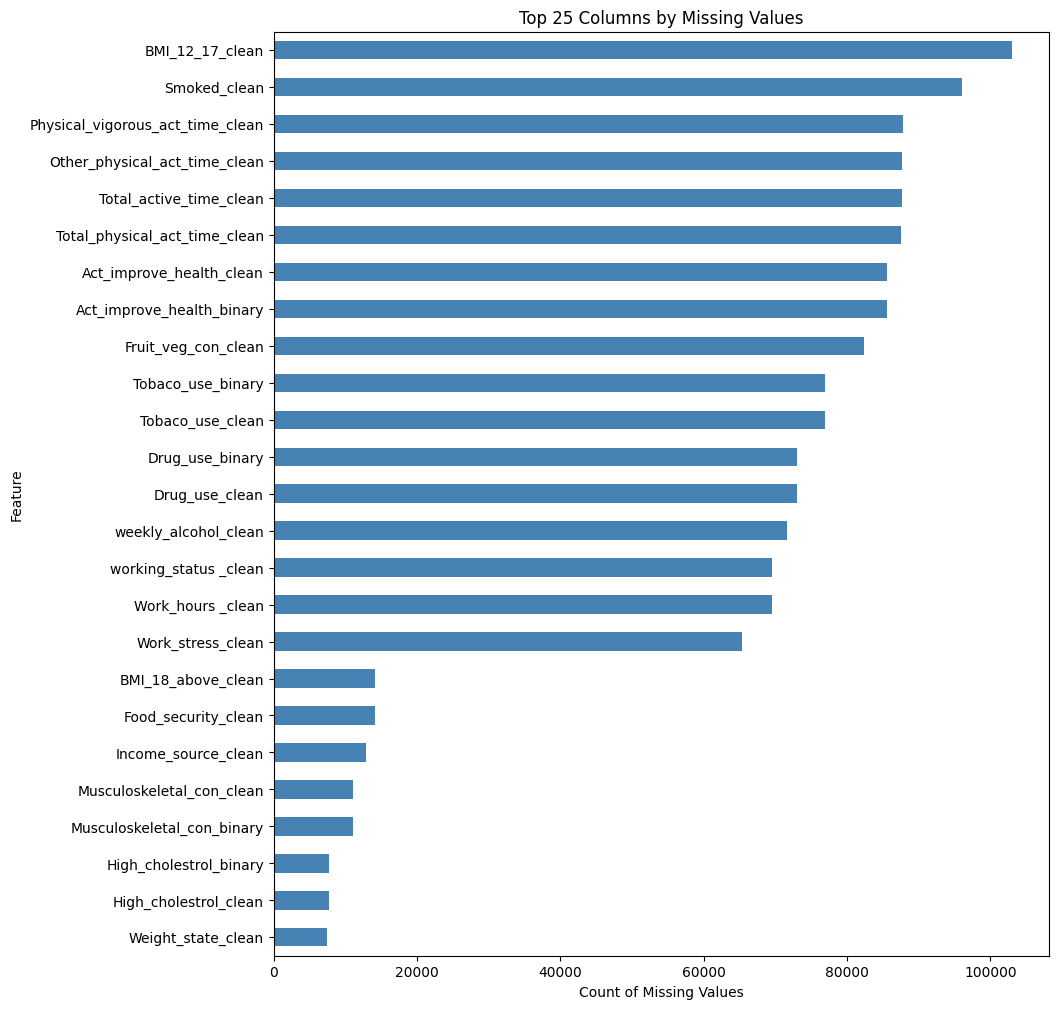

In [218]:
import matplotlib.pyplot as plt

# EDA Step 3: Missingness bar plot (top 25)
plt.figure(figsize=(10, 12))
missing_summary.head(25).plot.barh(color='steelblue')
plt.title("Top 25 Columns by Missing Values")
plt.xlabel("Count of Missing Values")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()


<Figure size 1200x800 with 0 Axes>

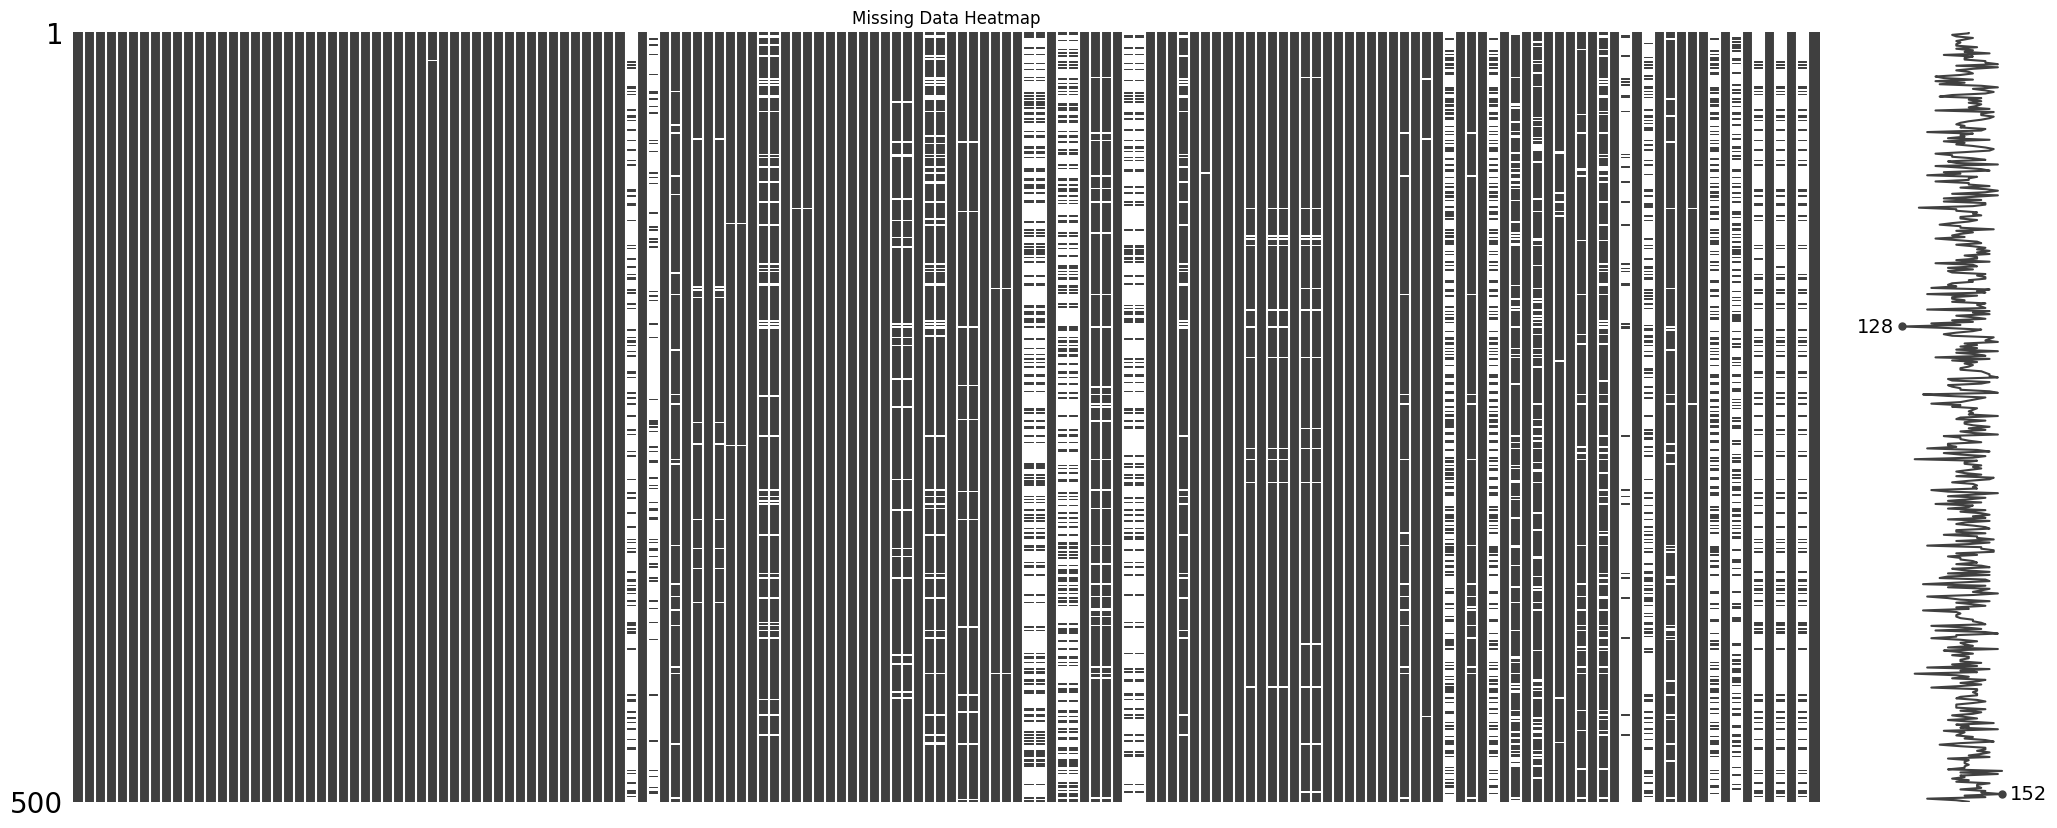

In [219]:
import missingno as msno

plt.figure(figsize=(12, 8))
msno.matrix(df_clean.sample(500))  # sample reduces rendering time
plt.title("Missing Data Heatmap")
plt.show()

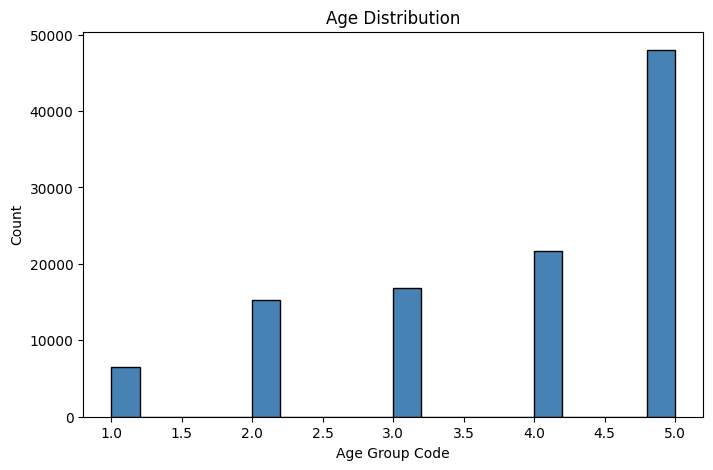

Age
1     6499
2    15277
3    16825
4    21684
5    47967
Name: count, dtype: int64

In [220]:
# EDA Step 4: Age distribution
plt.figure(figsize=(8,5))
df_clean["Age"].plot.hist(bins=20, color='steelblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age Group Code")
plt.ylabel("Count")
plt.show()

df_clean["Age"].value_counts().sort_index()


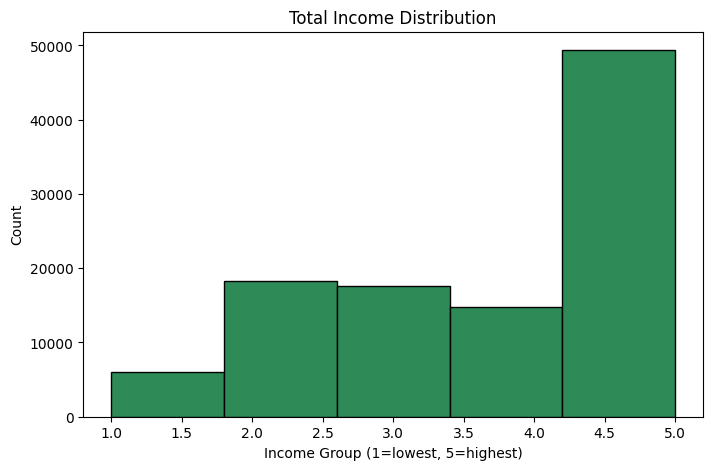

Total_income_clean
1.0     5998
2.0    18258
3.0    17565
4.0    14720
5.0    49386
Name: count, dtype: int64

In [221]:
# EDA Step 4: Total income distribution
plt.figure(figsize=(8,5))
df_clean["Total_income_clean"].plot.hist(bins=5, color='seagreen', edgecolor='black')
plt.title("Total Income Distribution")
plt.xlabel("Income Group (1=lowest, 5=highest)")
plt.ylabel("Count")
plt.show()

df_clean["Total_income_clean"].value_counts().sort_index()


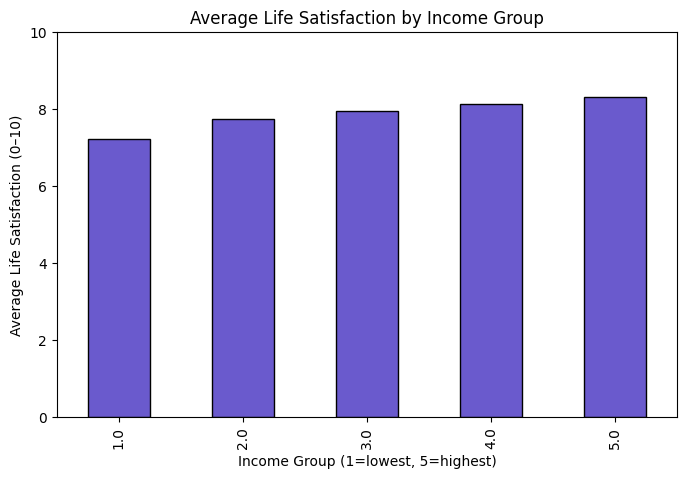

Total_income_clean
1.0    7.221222
2.0    7.743149
3.0    7.945741
4.0    8.114328
5.0    8.304483
Name: Life_satisfaction_clean, dtype: float64

In [222]:
# EDA: Mean Life Satisfaction by Income Group
income_life_mean = df_clean.groupby("Total_income_clean")["Life_satisfaction_clean"].mean()

plt.figure(figsize=(8,5))
income_life_mean.plot(kind="bar", color="slateblue", edgecolor="black")
plt.title("Average Life Satisfaction by Income Group")
plt.xlabel("Income Group (1=lowest, 5=highest)")
plt.ylabel("Average Life Satisfaction (0–10)")
plt.ylim(0, 10)
plt.show()

income_life_mean


<Figure size 1000x600 with 0 Axes>

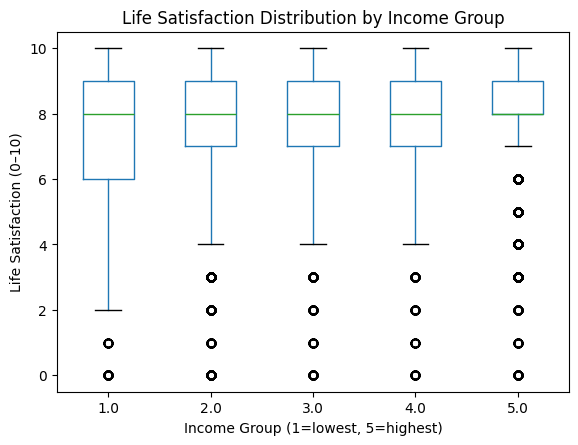

In [223]:
# EDA: Boxplot of Life Satisfaction by Income Group
plt.figure(figsize=(10,6))
df_clean.boxplot(column="Life_satisfaction_clean", by="Total_income_clean", grid=False)
plt.title("Life Satisfaction Distribution by Income Group")
plt.suptitle("")
plt.xlabel("Income Group (1=lowest, 5=highest)")
plt.ylabel("Life Satisfaction (0–10)")
plt.show()


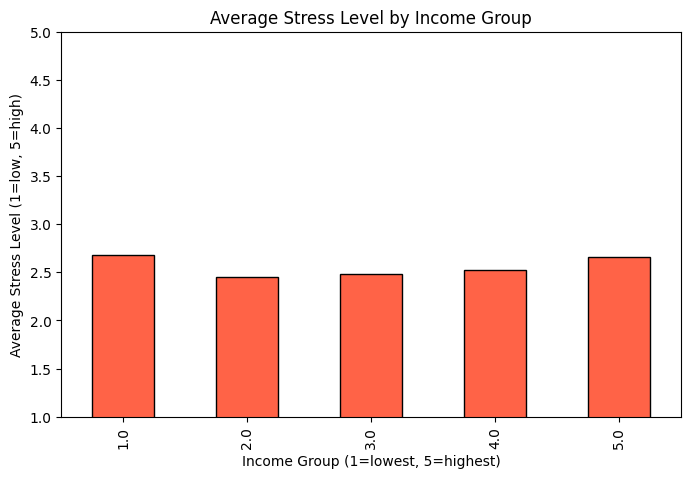

Total_income_clean
1.0    2.675322
2.0    2.447479
3.0    2.483888
4.0    2.527977
5.0    2.656152
Name: Stress_level_clean, dtype: float64

In [224]:
# EDA: Average Stress Level by Income Group
stress_mean = df_clean.groupby("Total_income_clean")["Stress_level_clean"].mean()

plt.figure(figsize=(8,5))
stress_mean.plot(kind="bar", color="tomato", edgecolor="black")
plt.title("Average Stress Level by Income Group")
plt.xlabel("Income Group (1=lowest, 5=highest)")
plt.ylabel("Average Stress Level (1=low, 5=high)")
plt.ylim(1, 5)
plt.show()

stress_mean


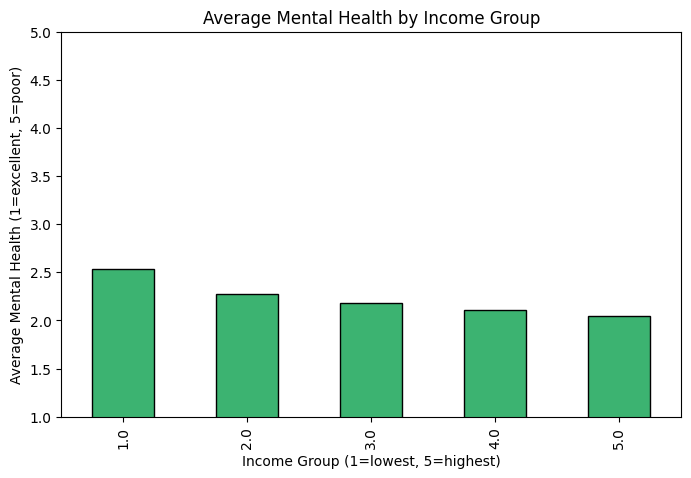

Total_income_clean
1.0    2.531513
2.0    2.273409
3.0    2.179719
4.0    2.104168
5.0    2.050308
Name: Mental_health_state_clean, dtype: float64

In [225]:
# EDA: Average Mental Health State by Income Group
mh_mean = df_clean.groupby("Total_income_clean")["Mental_health_state_clean"].mean()

plt.figure(figsize=(8,5))
mh_mean.plot(kind="bar", color="mediumseagreen", edgecolor="black")
plt.title("Average Mental Health by Income Group")
plt.xlabel("Income Group (1=lowest, 5=highest)")
plt.ylabel("Average Mental Health (1=excellent, 5=poor)")
plt.ylim(1, 5)
plt.show()

mh_mean


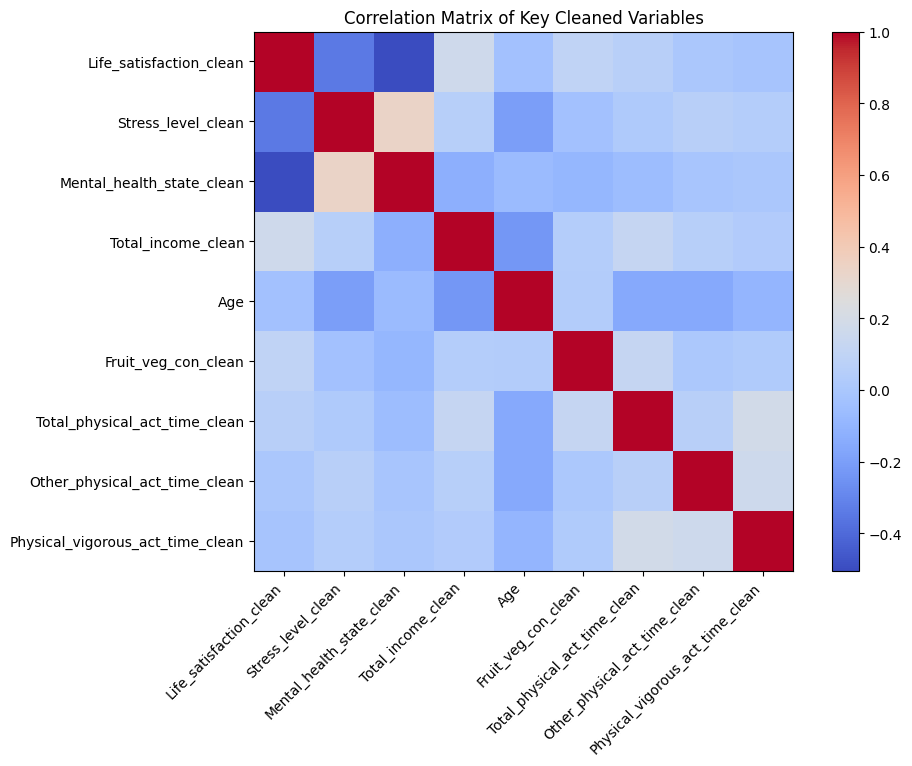

,Life_satisfaction_clean,Stress_level_clean,Mental_health_state_clean,Total_income_clean,Age,Fruit_veg_con_clean,Total_physical_act_time_clean,Other_physical_act_time_clean,Physical_vigorous_act_time_clean
Life_satisfaction_clean,1.000000,-0.340705,-0.503442,0.171102,-0.032851,0.098514,0.061561,0.003588,-0.010937
Stress_level_clean,-0.340705,1.000000,0.333304,0.058427,-0.200121,-0.028945,0.019988,0.062040,0.045229
Mental_health_state_clean,-0.503442,0.333304,1.000000,-0.123589,-0.063649,-0.089890,-0.056640,-0.008313,0.007486
Total_income_clean,0.171102,0.058427,-0.123589,1.000000,-0.227706,0.043578,0.124365,0.055051,0.036352
Age,-0.032851,-0.200121,-0.063649,-0.227706,1.000000,0.042131,-0.152752,-0.151374,-0.097716
Fruit_veg_con_clean,0.098514,-0.028945,-0.089890,0.043578,0.042131,1.000000,0.122352,0.011352,0.030478
Total_physical_act_time_clean,0.061561,0.019988,-0.056640,0.124365,-0.152752,0.122352,1.000000,0.065768,0.185245
Other_physical_act_time_clean,0.003588,0.062040,-0.008313,0.055051,-0.151374,0.011352,0.065768,1.000000,0.162303
Physical_vigorous_act_time_clean,-0.010937,0.045229,0.007486,0.036352,-0.097716,0.030478,0.185245,0.162303,1.000000


In [226]:
# EDA: Correlation matrix for selected clean numeric variables
numeric_cols = [
    "Life_satisfaction_clean",
    "Stress_level_clean",
    "Mental_health_state_clean",
    "Total_income_clean",
    "Age",
    "Fruit_veg_con_clean",
    "Total_physical_act_time_clean",
    "Other_physical_act_time_clean",
    "Physical_vigorous_act_time_clean",
]

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10,7))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar()
plt.title("Correlation Matrix of Key Cleaned Variables")
plt.show()

corr_matrix


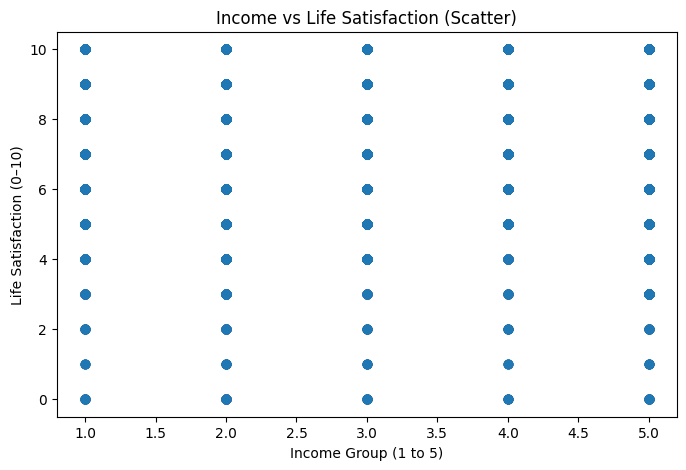

In [227]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean["Total_income_clean"], df_clean["Life_satisfaction_clean"], alpha=0.2)
plt.title("Income vs Life Satisfaction (Scatter)")
plt.xlabel("Income Group (1 to 5)")
plt.ylabel("Life Satisfaction (0–10)")
plt.show()


<Figure size 1000x600 with 0 Axes>

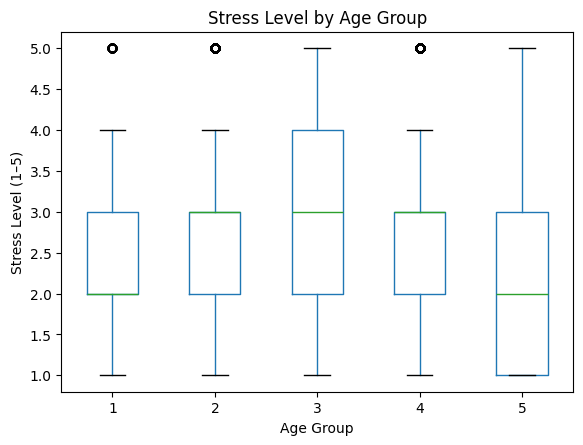

In [228]:
plt.figure(figsize=(10,6))
df_clean.boxplot(column="Stress_level_clean", by="Age", grid=False)
plt.title("Stress Level by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("Stress Level (1–5)")
plt.show()


<Figure size 1000x600 with 0 Axes>

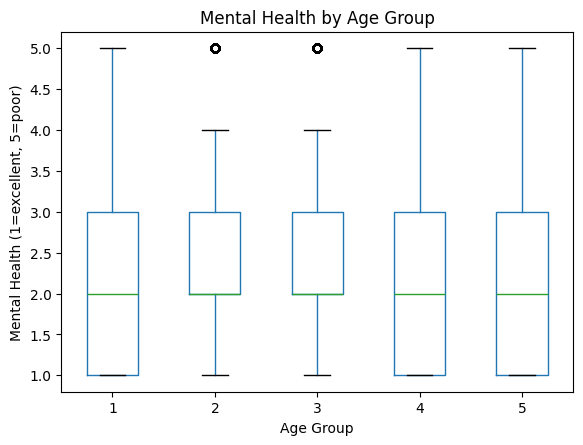

In [229]:
plt.figure(figsize=(10,6))
df_clean.boxplot(column="Mental_health_state_clean", by="Age", grid=False)
plt.title("Mental Health by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("Mental Health (1=excellent, 5=poor)")
plt.show()


<Figure size 1000x600 with 0 Axes>

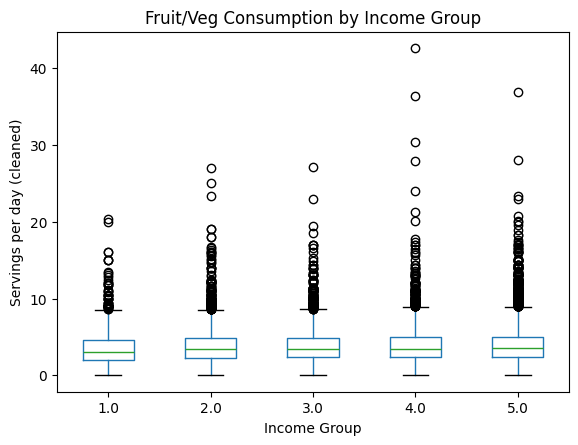

In [230]:
# Fruit & Veg Consumption by Income Group
plt.figure(figsize=(10,6))
df_clean.boxplot(column="Fruit_veg_con_clean", by="Total_income_clean", grid=False)
plt.title("Fruit/Veg Consumption by Income Group")
plt.suptitle("")
plt.xlabel("Income Group")
plt.ylabel("Servings per day (cleaned)")
plt.show()


<Figure size 1000x600 with 0 Axes>

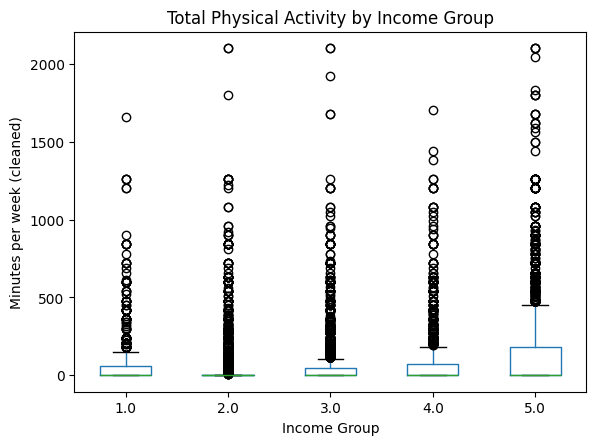

In [231]:
# Total Physical Activity by Income Group
plt.figure(figsize=(10,6))
df_clean.boxplot(column="Total_physical_act_time_clean", by="Total_income_clean", grid=False)
plt.title("Total Physical Activity by Income Group")
plt.suptitle("")
plt.xlabel("Income Group")
plt.ylabel("Minutes per week (cleaned)")
plt.show()


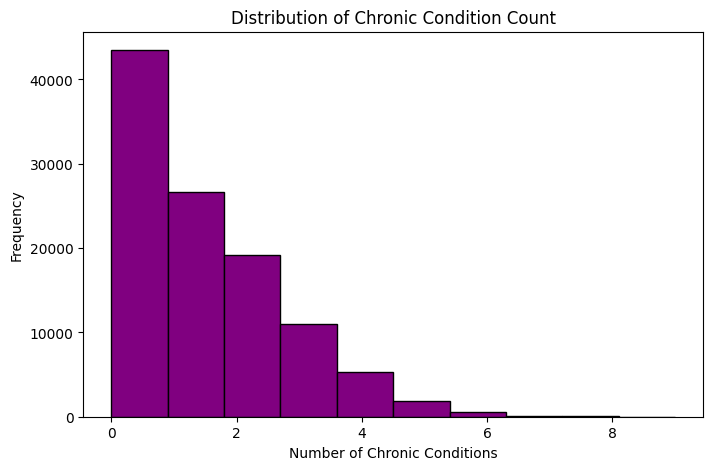

chronic_count
0.0    43480
1.0    26706
2.0    19236
3.0    10982
4.0     5267
5.0     1868
6.0      551
7.0      131
8.0       27
9.0        4
Name: count, dtype: int64

In [232]:
# Count how many chronic conditions each person has
chronic_cols = [
    "High_BP_binary",
    "High_cholestrol_binary",
    "Diabetic_binary",
    "Fatigue_syndrome_binary",
    "Mood_disorder_binary",
    "Anxiety_disorder_binary",
    "Respiratory_chronic_con_binary",
    "Musculoskeletal_con_binary",
    "Cardiovascular_con_binary"
]

df_clean["chronic_count"] = df_clean[chronic_cols].sum(axis=1)

plt.figure(figsize=(8,5))
df_clean["chronic_count"].plot.hist(bins=10, color="purple", edgecolor="black")
plt.title("Distribution of Chronic Condition Count")
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Frequency")
plt.show()

df_clean["chronic_count"].value_counts().sort_index()


<Figure size 1000x600 with 0 Axes>

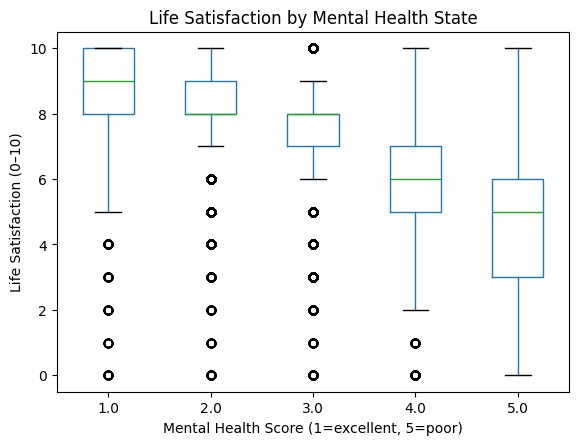

In [233]:
# Life Satisfaction Across Mental Health Levels
plt.figure(figsize=(10,6))
df_clean.boxplot(column="Life_satisfaction_clean", by="Mental_health_state_clean", grid=False)
plt.title("Life Satisfaction by Mental Health State")
plt.suptitle("")
plt.xlabel("Mental Health Score (1=excellent, 5=poor)")
plt.ylabel("Life Satisfaction (0–10)")
plt.show()


In [234]:
# Select modeling features

feature_cols = [
    # Demographics
    "Age", "Gender_clean", "Marital_status_clean", "Household_clean",
    
    # Socioeconomic
    "Total_income_clean", "Income_source_clean", "Food_security_clean",
    
    # Health states
    "Gen_health_state_clean", "Mental_health_state_clean",
    "Stress_level_clean", "Work_stress_clean",
    
    # Behaviors
    "Fruit_veg_con_clean", "Total_physical_act_time_clean",
    "Other_physical_act_time_clean", "Physical_vigorous_act_time_clean",
    "weekly_alcohol_clean", "Smoked_clean",
    
    # Chronic condition binaries
    "High_BP_binary", "High_cholestrol_binary", "Diabetic_binary",
    "Mood_disorder_binary", "Anxiety_disorder_binary",
    "Musculoskeletal_con_binary", "Respiratory_chronic_con_binary",
    "Cardiovascular_con_binary",
]

target_col = "Life_satisfaction_clean"

df_model = df_clean[feature_cols + [target_col]].copy()

df_model.head()


,Age,Gender_clean,Marital_status_clean,Household_clean,Total_income_clean,Income_source_clean,Food_security_clean,Gen_health_state_clean,Mental_health_state_clean,Stress_level_clean,...,Smoked_clean,High_BP_binary,High_cholestrol_binary,Diabetic_binary,Mood_disorder_binary,Anxiety_disorder_binary,Musculoskeletal_con_binary,Respiratory_chronic_con_binary,Cardiovascular_con_binary,Life_satisfaction_clean
0,3,2.0,1.0,2.0,5.0,1.0,0.0,3.0,3.0,2.0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0
1,5,1.0,1.0,2.0,4.0,2.0,0.0,3.0,3.0,3.0,...,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0
2,5,2.0,2.0,1.0,2.0,2.0,NaN,2.0,3.0,3.0,...,NaN,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,7.0
3,5,1.0,2.0,1.0,3.0,2.0,0.0,3.0,3.0,3.0,...,NaN,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0
4,4,1.0,2.0,1.0,1.0,2.0,0.0,5.0,5.0,4.0,...,NaN,1.0,0.0,NaN,0.0,0.0,1.0,NaN,NaN,0.0


In [235]:
df_model.isna().sum().sort_values(ascending=False)


Smoked_clean                        96034
Physical_vigorous_act_time_clean    87855
Other_physical_act_time_clean       87674
Total_physical_act_time_clean       87594
Fruit_veg_con_clean                 82329
weekly_alcohol_clean                71578
Work_stress_clean                   65389
Food_security_clean                 14172
Income_source_clean                 12844
Musculoskeletal_con_binary          11038
High_cholestrol_binary               7753
Marital_status_clean                 6874
Respiratory_chronic_con_binary       5573
Life_satisfaction_clean              4200
Cardiovascular_con_binary            4117
Mental_health_state_clean            3739
Diabetic_binary                      2665
Total_income_clean                   2325
Household_clean                       522
Stress_level_clean                    429
High_BP_binary                        408
Anxiety_disorder_binary               222
Mood_disorder_binary                  201
Gen_health_state_clean            

In [236]:
from sklearn.impute import SimpleImputer

# Separate numeric and categorical
numeric_feats = df_model.select_dtypes(include=['float64', 'int64']).columns

imputer = SimpleImputer(strategy="median")
df_model[numeric_feats] = imputer.fit_transform(df_model[numeric_feats])

df_model.isna().sum().sum()


np.int64(0)

In [237]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((86601, 25), (21651, 25))

In [238]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))


MAE: 1.0302416284806308
R2: 0.2958594808705408


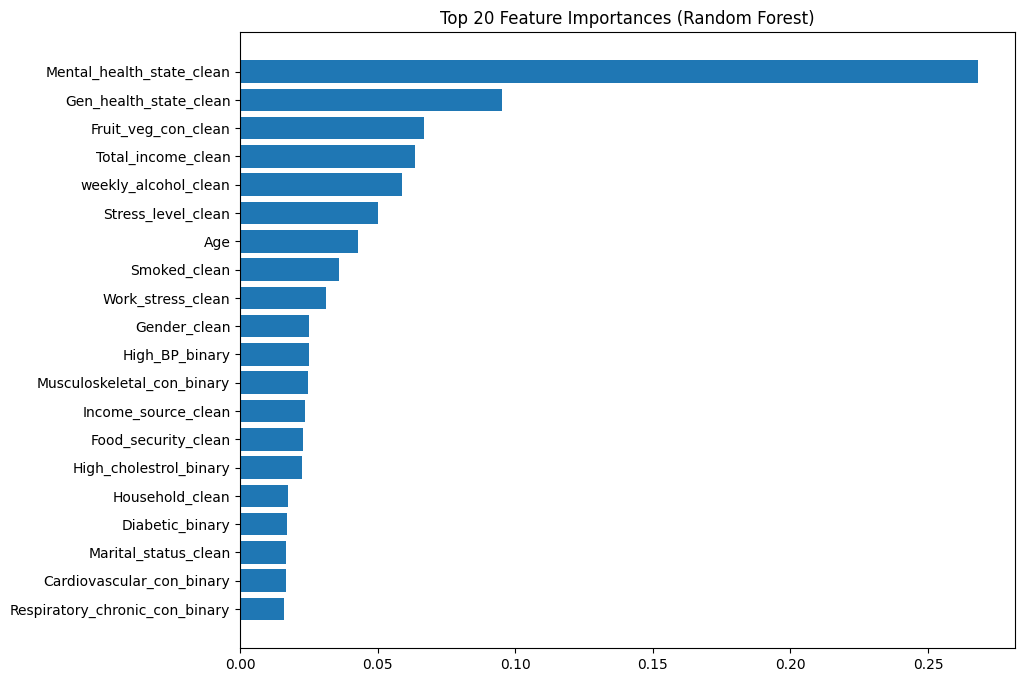

,feature,importance
8,Mental_health_state_clean,0.268235
7,Gen_health_state_clean,0.095299
11,Fruit_veg_con_clean,0.066861
4,Total_income_clean,0.063566
15,weekly_alcohol_clean,0.058820
9,Stress_level_clean,0.049984
0,Age,0.042949
16,Smoked_clean,0.035998
10,Work_stress_clean,0.031371
1,Gender_clean,0.025088


In [239]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_
fi_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,8))
plt.barh(fi_df["feature"].head(20), fi_df["importance"].head(20))
plt.title("Top 20 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

fi_df.head(20)


In [240]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

gbr_preds = gbr.predict(X_test)

print("GBR MAE:", mean_absolute_error(y_test, gbr_preds))
print("GBR R2 :", r2_score(y_test, gbr_preds))


GBR MAE: 0.9544872628986761
GBR R2 : 0.39390230259480863


In [241]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print("LR MAE:", mean_absolute_error(y_test, lr_preds))
print("LR R2 :", r2_score(y_test, lr_preds))


LR MAE: 0.9640513768980696
LR R2 : 0.37440612779327287


In [242]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "Linear Regression"],
    "MAE": [
        mean_absolute_error(y_test, preds),
        mean_absolute_error(y_test, gbr_preds),
        mean_absolute_error(y_test, lr_preds)
    ],
    "R2": [
        r2_score(y_test, preds),
        r2_score(y_test, gbr_preds),
        r2_score(y_test, lr_preds)
    ]
})

results


,Model,MAE,R2
0,Random Forest,1.030242,0.295859
1,Gradient Boosting,0.954487,0.393902
2,Linear Regression,0.964051,0.374406


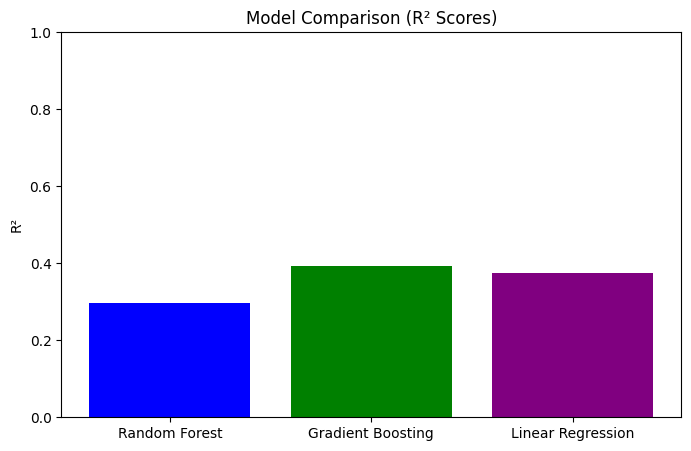

In [243]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2"], color=["blue","green","purple"])
plt.title("Model Comparison (R² Scores)")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.show()


In [244]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [245]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0]
}

grid = GridSearchCV(
    gbr,
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV R2:", grid.best_score_)


Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV R2: 0.3882833852373704


In [246]:
best_gbr = grid.best_estimator_

test_preds = best_gbr.predict(X_test)

print("Final MAE:", mean_absolute_error(y_test, test_preds))
print("Final R2 :", r2_score(y_test, test_preds))


Final MAE: 0.9545302108706695
Final R2 : 0.39399828678951465


In [247]:
import joblib
joblib.dump(best_gbr, "best_life_satisfaction_model.pkl")
print("Model saved as best_life_satisfaction_model.pkl")


Model saved as best_life_satisfaction_model.pkl


In [248]:
def predict_life_satisfaction(user_input_dict):
    import numpy as np

    # Convert dict → model feature vector
    x = np.array([user_input_dict[col] for col in X.columns]).reshape(1, -1)
    return float(best_gbr.predict(x)[0])

# Example dummy input
predict_life_satisfaction({
    col: X_train.iloc[0][col] for col in X.columns
})


c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


8.273414476054242

In [249]:
import gradio as gr
import joblib
import numpy as np

model = joblib.load("best_life_satisfaction_model.pkl")

def predict_func(*inputs):
    x = np.array(inputs).reshape(1, -1)
    pred = model.predict(x)[0]
    return round(float(pred), 2)

iface = gr.Interface(
    fn=predict_func,
    inputs=[gr.Slider(0,10,label=col) for col in X.columns],  # simple version
    outputs="number",
    title="Life Satisfaction Predictor"
)

iface.launch()


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [250]:
# Robust single-row prediction using DataFrame (use X.columns as reference)
import pandas as pd
def predict_life_satisfaction(user_input_dict):
    # user_input_dict: {feature_name: value, ...}
    x_df = pd.DataFrame([user_input_dict], columns=X.columns)
    return float(best_gbr.predict(x_df)[0])


In [251]:
import joblib
joblib.dump({"model": best_gbr, "features": list(X.columns)}, "artifact_best_model_with_meta.pkl")


['artifact_best_model_with_meta.pkl']

In [252]:
import pandas as pd
import joblib
artifact = joblib.load("artifact_best_model_with_meta.pkl")
best_model = artifact["model"]
FEATURE_COLUMNS = artifact["features"]

def predict_life_satisfaction_row(user_input_dict):
    # Ensure all required features are present
    missing = [c for c in FEATURE_COLUMNS if c not in user_input_dict]
    if missing:
        raise ValueError(f"Missing features: {missing}")

    x = pd.DataFrame([user_input_dict], columns=FEATURE_COLUMNS)
    return float(best_model.predict(x)[0])

# Example usage:
sample_input = {col: float(X_train.iloc[0][col]) for col in FEATURE_COLUMNS}
print("Pred:", predict_life_satisfaction_row(sample_input))


Pred: 8.273414476054242


In [253]:
import pandas as pd
import joblib
artifact = joblib.load("artifact_best_model_with_meta.pkl")
best_model = artifact["model"]
FEATURE_COLUMNS = artifact["features"]

def predict_life_satisfaction_row(user_input_dict):
    # Ensure all required features are present
    missing = [c for c in FEATURE_COLUMNS if c not in user_input_dict]
    if missing:
        raise ValueError(f"Missing features: {missing}")

    x = pd.DataFrame([user_input_dict], columns=FEATURE_COLUMNS)
    return float(best_model.predict(x)[0])

# Example usage:
sample_input = {col: float(X_train.iloc[0][col]) for col in FEATURE_COLUMNS}
print("Pred:", predict_life_satisfaction_row(sample_input))


Pred: 8.273414476054242


In [254]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_cols = X.columns.tolist()  # all numeric here
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(**grid.best_params_, random_state=42))
])

# Fit pipeline on training data
pipe.fit(X_train, y_train)

# Evaluate
preds_pipe = pipe.predict(X_test)
print("Pipeline MAE:", mean_absolute_error(y_test, preds_pipe))
print("Pipeline R2 :", r2_score(y_test, preds_pipe))

# Save pipeline
joblib.dump(pipe, "pipeline_life_satisfaction.pkl")


Pipeline MAE: 0.9544252919496162
Pipeline R2 : 0.39409314721502564


['pipeline_life_satisfaction.pkl']

In [255]:
# Save cleaned CSV
df_clean.to_csv("health_dataset_cleaned.csv", index=False)

# Save model metrics
metrics = {"MAE": mean_absolute_error(y_test, preds),
           "R2": r2_score(y_test, preds)}
import json
with open("metrics.json","w") as f:
    json.dump(metrics, f)

# Save feature importance table as CSV
fi_df.to_csv("feature_importances.csv", index=False)

# Save a short text summary
with open("summary.txt","w") as f:
    f.write(f"Best params: {grid.best_params_}\n")
    f.write(f"Final MAE: {metrics['MAE']}\nFinal R2: {metrics['R2']}\n")


In [256]:
# Cell A — create binary target
# (Run after df_model exists from earlier steps)

import numpy as np

# create binary target: low satisfaction (1) if Life_satisfaction_clean <= 5, else 0
df_model["low_sat"] = (df_model["Life_satisfaction_clean"] <= 5).astype(int)

# class balance check
df_model["low_sat"].value_counts(normalize=False), df_model["low_sat"].value_counts(normalize=True)


(low_sat
 0    99452
 1     8800
 Name: count, dtype: int64,
 low_sat
 0    0.918708
 1    0.081292
 Name: proportion, dtype: float64)

In [258]:
# Cell B — LightGBM classifier training with pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix
import lightgbm as lgb

X = df_model.drop(columns=["Life_satisfaction_clean", "low_sat"])
y = df_model["low_sat"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# simple pipeline (imputer + scaler — LightGBM doesn't need scaling, but pipeline keeps preprocessing consistent)
pipe_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1))
])

pipe_clf.fit(X_train, y_train)

# predictions & scores
probs = pipe_clf.predict_proba(X_test)[:,1]
preds = pipe_clf.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, probs))
print("PR-AUC :", average_precision_score(y_test, probs))
print(classification_report(y_test, preds, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, preds))


[LightGBM] [Info] Number of positive: 7040, number of negative: 79561
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006215 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 86601, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081292 -> initscore=-2.424916
[LightGBM] [Info] Start training from score -2.424916


c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC: 0.8840469479115727
PR-AUC : 0.490810743388228
              precision    recall  f1-score   support

           0      0.940     0.985     0.962     19891
           1      0.627     0.289     0.395      1760

    accuracy                          0.928     21651
   macro avg      0.784     0.637     0.679     21651
weighted avg      0.915     0.928     0.916     21651

Confusion matrix:
 [[19589   302]
 [ 1252   508]]


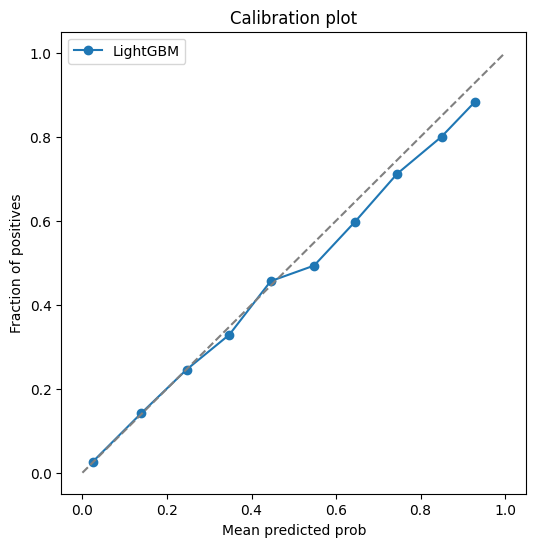

[LightGBM] [Info] Number of positive: 4694, number of negative: 53040
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003834 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train set: 57734, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081304 -> initscore=-2.424761
[LightGBM] [Info] Start training from score -2.424761


c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 4693, number of negative: 53041
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 574
[LightGBM] [Info] Number of data points in the train set: 57734, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081287 -> initscore=-2.424993
[LightGBM] [Info] Start training from score -2.424993


c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 4693, number of negative: 53041
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 561
[LightGBM] [Info] Number of data points in the train set: 57734, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081287 -> initscore=-2.424993
[LightGBM] [Info] Start training from score -2.424993


c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Calibrated ROC-AUC: 0.8849448242923936


In [259]:
# Cell C — calibration curve (reliability diagram) and optional calibration
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV

# calibration curve
prob_pos = probs
frac_pos, mean_pred = calibration_curve(y_test, prob_pos, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(mean_pred, frac_pos, marker='o', label='LightGBM')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("Mean predicted prob")
plt.ylabel("Fraction of positives")
plt.title("Calibration plot")
plt.legend()
plt.show()

# If needed, calibrate with isotonic or sigmoid
calibrator = CalibratedClassifierCV(pipe_clf, cv=3, method='isotonic')
calibrator.fit(X_train, y_train)
cal_probs = calibrator.predict_proba(X_test)[:,1]
print("Calibrated ROC-AUC:", roc_auc_score(y_test, cal_probs))


c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


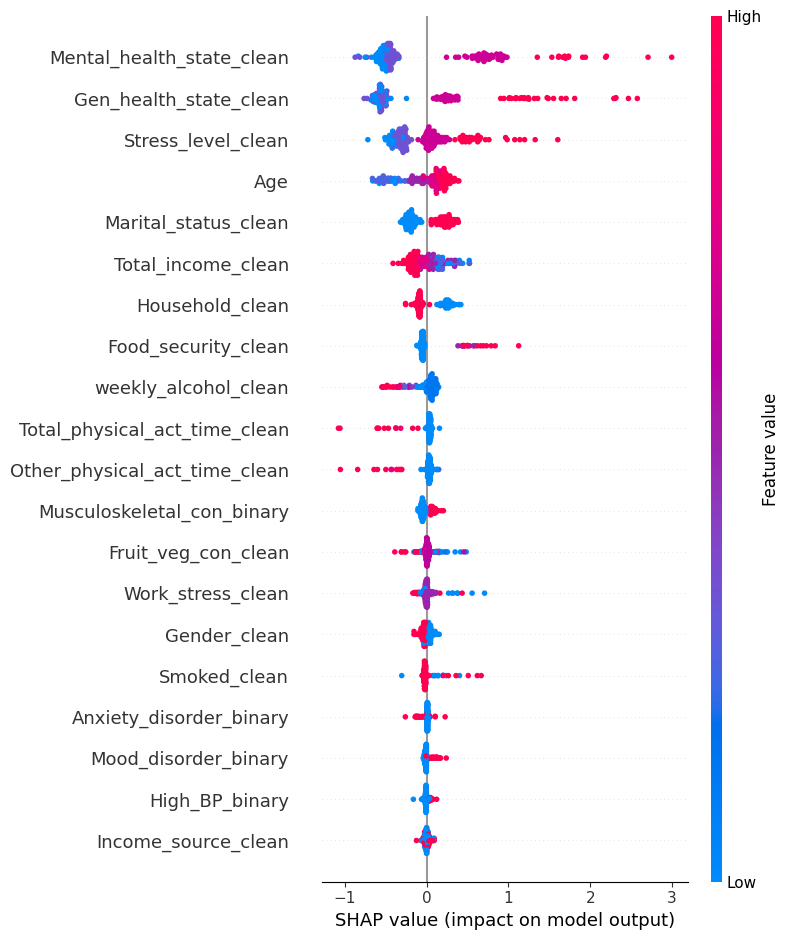

True label: 0
Pred prob: 0.1565189024169781


c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


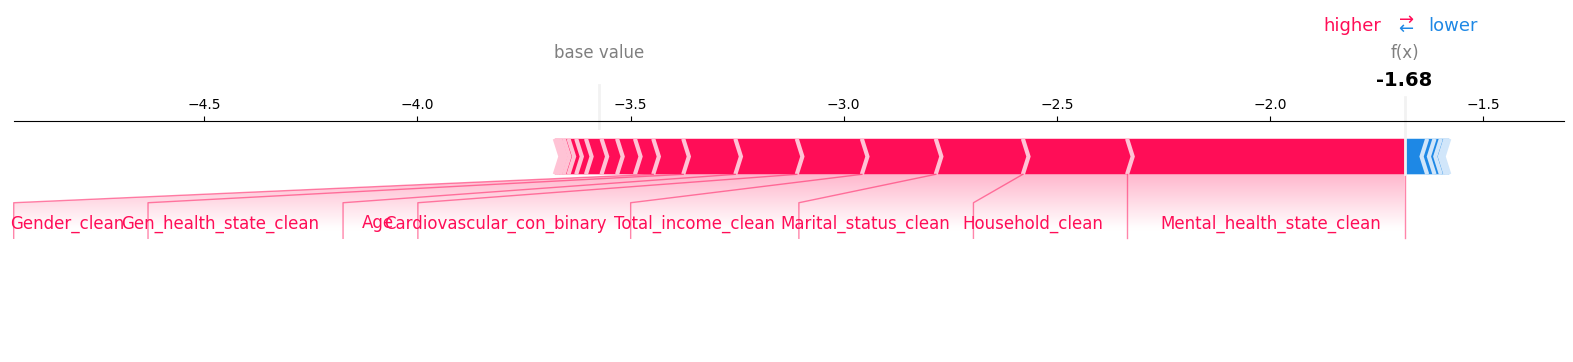

In [261]:
# Cell D — SHAP explanation (robust to scalar vs array expected_value / shap_values shapes)
import shap
import numpy as np

# Use raw model inside pipeline
model_for_shap = pipe_clf.named_steps["model"]

# Preprocess X_test using pipeline steps
X_test_pre = pipe_clf.named_steps["imputer"].transform(X_test)
X_test_pre = pipe_clf.named_steps["scaler"].transform(X_test_pre)

explainer = shap.TreeExplainer(model_for_shap)

# pass a small sample to keep plot fast
sample = X_test_pre[:200]
shap_values = explainer.shap_values(sample)

# Summary plot (global)
shap.summary_plot(shap_values, features=sample, feature_names=X.columns, show=True)

# Local explanation for a single example
i = 5  # index in sample
# use the pipeline to get a reliable predicted probability for the original feature ordering
print("True label:", y_test.iloc[:200].iloc[i])
pred_prob = pipe_clf.predict_proba(X_test.iloc[:200].iloc[i:i+1])[0,1]
print("Pred prob:", pred_prob)

# Handle different shap output formats:
# - shap_values can be a list (multiclass / per-class arrays) or a 2D array (samples x features)
# - explainer.expected_value can be scalar or an array
if isinstance(shap_values, list):
	# binary classifier (list of arrays) or multiclass: use class-1 explanations
	sv = shap_values[1][i]
	ev = explainer.expected_value[1] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value
else:
	# shap_values is 2D: (n_samples, n_features)
	sv = shap_values[i]
	ev = explainer.expected_value
	if hasattr(ev, "__len__") and len(ev) > 1:
		# choose class-1 expected value when shap returned a vector
		ev = ev[1]

shap.force_plot(ev, sv, feature_names=X.columns, matplotlib=True)


In [264]:
# Cell E — save artifacts
import joblib
joblib.dump(pipe_clf, "lgbm_low_satisfaction_clf.pkl")

# Compute mean(|SHAP|) importances and save top 20
import numpy as np
shap_abs_mean = np.mean(np.abs(shap_values[1]), axis=0)  # class 1 shap
shap_df = pd.DataFrame({"feature": X.columns, "shap_mean_abs": shap_abs_mean})
shap_df.sort_values("shap_mean_abs", ascending=False).head(20).to_csv("shap_feature_importance.csv", index=False)
print("Saved classifier and SHAP importances.")


Saved classifier and SHAP importances.


In [266]:
# Cell F — simple Gradio UI for classification prediction
import gradio as gr
import numpy as np
pipe = joblib.load("lgbm_low_satisfaction_clf.pkl")

def predict_and_explain(*vals):
    arr = np.array(vals).reshape(1,-1)
    # apply pipeline steps: impute+scale inside pipe
    prob = pipe.predict_proba(arr)[0,1]
    pred = int(pipe.predict(arr)[0])
    return {"prob_low_satisfaction": float(prob), "pred_label": int(pred)}

inputs = [gr.Number(label=col, value=float(X[col].median())) for col in X.columns]
iface = gr.Interface(fn=predict_and_explain, inputs=inputs, outputs=["label","number"], title="Low Satisfaction Classifier")
iface.launch()


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Traceback (most recent call last):
  File "c:\Users\savin\AppData\Local\Programs\Python\Python312\Lib\site-pac